# Imports


In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import networkx as nx
from scipy.stats import fisher_exact
from pyvis.network import Network
import numpy as np

sns.set_theme(style="whitegrid")


# Filter all the file to obtain just the chosen info (filtri scelti sul portale)


## Filter raws for mutation, sv e gene panel file


In [ ]:
import pandas as pd
import os

def filter_samples_by_id(reference_filename, target_files_list, cohort_path, source_data_path, output_prefix="F_"):
    """
    Legge il file master da cohort_path.
    Legge i file originali da source_data_path.
    Salva i file filtrati in cohort_path.
    """
    # 1. Costruisco il path completo del file di riferimento (dentro la cartella del tumore)
    reference_csv_path = os.path.join(cohort_path, reference_filename)
    
    try:
        # Carichiamo il master
        ref_df = pd.read_csv(reference_csv_path, sep='\t')
        valid_ids = set(ref_df['Sample_Id'].astype(str).unique())
        print(f"\n--- Analisi Coorte: {os.path.basename(cohort_path.strip('/'))} ---")
        print(f"Caricati {len(valid_ids)} ID univoci dal master {reference_filename}.")
    except Exception as e:
        print(f"Errore caricamento master {reference_csv_path}: {e}")
        return

    # 2. Cicla sui file originali presenti in O_data
    for filename in target_files_list:
        file_input_path = os.path.join(source_data_path, filename)
        
        if not os.path.exists(file_input_path):
            print(f"File originale non trovato in {file_input_path}, salto...")
            continue
            
        print(f"Filtraggio in corso per: {filename}...")
        # Aggiunto low_memory=False per evitare i DtypeWarning visti in precedenza
        target_df = pd.read_csv(file_input_path, sep='\t', low_memory=False)
        
        if 'Sample_Id' in target_df.columns:
            # Filtro righe
            filtered_df = target_df[target_df['Sample_Id'].astype(str).isin(valid_ids)]
            
            # 3. Salvataggio dentro la cartella del tumore specifica
            output_name = f"{output_prefix}{filename}"
            output_full_path = os.path.join(cohort_path, output_name)
            
            filtered_df.to_csv(output_full_path, index=False, sep='\t')
            print(f"Righe originali: {len(target_df)} -> Filtrate: {len(filtered_df)}")
            print(f"Salvato in: {output_full_path}")
        else:
            print(f"Colonna 'Sample_Id' non trovata in {filename}. File saltato.")

# --- CONFIGURAZIONE PATH ---

# Cartella con i file originali enormi
source_path = "./O_data"

# Lista dei nomi dei file da pescare in O_data
file_da_filtrare = ["data_mutations.txt"] 

# --- ESECUZIONE PER LE DIVERSE COORTI ---

# KRAS PANCREAS
filter_samples_by_id('F_pancreas.csv', file_da_filtrare, "./kras_pancreas/", source_path)

# KRAS LUNG
filter_samples_by_id('F_lung.csv', file_da_filtrare, "./kras_lung/", source_path)

# KRAS COLON
filter_samples_by_id('F_colon.csv', file_da_filtrare, "./kras_colon/", source_path)


--- Analisi cartella: ./kras_pancreas/ ---
Caricati 1672 ID univoci dal master.
Filtraggio in corso per: data_mutations.txt...


C:\Users\miche\AppData\Local\Temp\ipykernel_22256\1443711615.py:28: DtypeWarning: Columns (0: Exon_Number, 1: ALLELE_NUM, 2: IS_NEW) have mixed types. Specify dtype option on import or set low_memory=False.
  target_df = pd.read_csv(file_input_path, sep='\t')


Righe originali in data_mutations.txt: 208544
Salvato: F_data_mutations.txt (7115 righe mantenute)

--- Analisi cartella: ./kras_lung/ ---
Caricati 3833 ID univoci dal master.
Filtraggio in corso per: data_mutations.txt...


C:\Users\miche\AppData\Local\Temp\ipykernel_22256\1443711615.py:28: DtypeWarning: Columns (0: Exon_Number, 1: ALLELE_NUM, 2: IS_NEW) have mixed types. Specify dtype option on import or set low_memory=False.
  target_df = pd.read_csv(file_input_path, sep='\t')


Righe originali in data_mutations.txt: 208544
Salvato: F_data_mutations.txt (33990 righe mantenute)

--- Analisi cartella: ./kras_colon/ ---
Caricati 2347 ID univoci dal master.
Filtraggio in corso per: data_mutations.txt...


C:\Users\miche\AppData\Local\Temp\ipykernel_22256\1443711615.py:28: DtypeWarning: Columns (0: Exon_Number, 1: ALLELE_NUM, 2: IS_NEW) have mixed types. Specify dtype option on import or set low_memory=False.
  target_df = pd.read_csv(file_input_path, sep='\t')


Righe originali in data_mutations.txt: 208544
Salvato: F_data_mutations.txt (41821 righe mantenute)


### Filter the columns of cna file


In [ ]:
def filter_columns_by_master(path, master_path, target_path, output_path):

    if not os.path.exists(f"{path}/{master_path}"):
        print(f"File not found: {path}/{master_path}. Skipping this cohort.")
        return

    master_df = pd.read_csv(f"{path}/{master_path}", sep='\t')
    
    # Crea un set di Sample_Id validi
    valid_ids = set(master_df['Sample_Id'].astype(str).unique())
    print(f"ID univoci trovati nel master: {len(valid_ids)}")

    # 2. Carica il file target (quello da cui levare le colonne)
    target_df = pd.read_csv(f"{path}/{target_path}", sep='\t')
    print(f"Shape del target_df: {target_df.shape}")
    
    # 3. Identifica le colonne da tenere
    # Vogliamo tenere 'Hugo_Symbol' (o altre colonne descrittive iniziali) 
    # E tutte le colonne il cui nome è presente in valid_ids
    columns_to_keep = []
    columns_removed = 0
    
    for col in target_df.columns:
        if col == 'Hugo_Symbol' or col in valid_ids:
            columns_to_keep.append(col)
        else:
            columns_removed += 1
            
    # 4. Filtra il dataframe
    filtered_df = target_df[columns_to_keep]
    
    # 5. Salva il risultato
    filtered_df.to_csv(f"{path}/{output_path}", sep='\t', index=False)
    
    print(f"Colonne totali rimosse: {columns_removed}")
    print(f"Colonne rimaste: {len(columns_to_keep)}")
    print(f"File salvato in: {path}/{output_path}")



path = "./kras_pancreas"
filter_columns_by_master(path, 'F_pancreas.csv', 'data_cna.txt', 'F_data_cna.txt')

path = "./kras_lung"
filter_columns_by_master(path, 'F_lung.csv', 'data_cna.txt', 'F_data_cna.csv')

path = "./kras_colon"
filter_columns_by_master(path, 'F_colon.csv', 'data_cna.txt', 'F_data_cna.csv')

ID univoci trovati nel master: 1672
Shape del target_df: (702, 25035)
Colonne totali rimosse: 23365
Colonne rimaste: 1670
File salvato in: ./kras_pancreas/F_data_cna.txt
ID univoci trovati nel master: 3833
Shape del target_df: (702, 25035)
Colonne totali rimosse: 21201
Colonne rimaste: 3834
File salvato in: ./kras_lung/F_data_cna.csv
ID univoci trovati nel master: 2347
Shape del target_df: (702, 25035)
Colonne totali rimosse: 22688
Colonne rimaste: 2347
File salvato in: ./kras_colon/F_data_cna.csv


### Colonne sus


In [28]:
import pandas as pd
import numpy as np

# Carichiamo il file (usiamo low_memory=False solo per l'ispezione)
path_test = "./kras_pancreas/data_mutations.txt"
df = pd.read_csv(path_test, sep='\t', low_memory=False)

indices_incriminati = [44, 49, 88]

print("--- ANALISI COLONNE MIXED TYPES ---")

for idx in indices_incriminati:
    col_name = df.columns[idx]
    print(f"\nColonna {idx}: '{col_name}'")
    
    # Vediamo i tipi di dati reali presenti
    tipi_rilevati = df.iloc[:, idx].apply(lambda x: type(x)).unique()
    print(f"Tipi Python trovati: {tipi_rilevati}")
    
    # Mostriamo i primi 10 valori unici per capire il contenuto
    valori_unici = df.iloc[:, idx].unique()[:10]
    print(f"Esempio valori: {valori_unici}")
    
    # Controlliamo se ci sono stringhe che dovrebbero essere numeri
    n_stringhe = df.iloc[:, idx].apply(lambda x: isinstance(x, str)).sum()
    print(f"Numero di righe con testo (str): {n_stringhe}")

--- ANALISI COLONNE MIXED TYPES ---

Colonna 44: 'Exon_Number'
Tipi Python trovati: [<class 'float'> <class 'str'>]
Esempio valori: <StringArray>
[     nan,  '1-Jan',  '3-Jan',  '22/22',  '9-Jan', 'Jan-33', '1/3/08',
  '4-Jan', '20-Jan', '16-Jan']
Length: 10, dtype: str
Numero di righe con testo (str): 16

Colonna 49: 'ALLELE_NUM'
Tipi Python trovati: [<class 'float'> <class 'str'>]
Esempio valori: <StringArray>
[nan, 'NEWRECORD']
Length: 2, dtype: str
Numero di righe con testo (str): 16236

Colonna 88: 'IS_NEW'
Tipi Python trovati: [<class 'float'> <class 'str'>]
Esempio valori: <StringArray>
[nan, 'NEWRECORD']
Length: 2, dtype: str
Numero di righe con testo (str): 12258


 # DATA STATISTICS

## Roba generica

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

# Soppressione di tutti i warning (es. DtypeWarning sui file grandi o warning di Seaborn)
warnings.filterwarnings('ignore')

def analyze_cohort_stats(cohort_path, master_filename, mut_filename, cna_filename, top_n=20):
    """
    Calcola le statistiche di mutazioni, CNA e dati clinici.
    """
    cohort_name = os.path.basename(cohort_path.strip('/'))
    print(f"\n" + "="*50)
    print(f"📊 ANALISI COORTE: {cohort_name.upper()}")
    print(f"="*50)
    
    master_path = os.path.join(cohort_path, master_filename)
    mut_path = os.path.join(cohort_path, mut_filename)
    
    cna_path_csv = os.path.join(cohort_path, cna_filename.replace('.txt', '.csv'))
    cna_path_txt = os.path.join(cohort_path, cna_filename.replace('.csv', '.txt'))
    cna_path = cna_path_csv if os.path.exists(cna_path_csv) else cna_path_txt
    
    # --- 1. ANALISI CLINICA E PAZIENTI (File Master) ---
    df_clin = None
    if os.path.exists(master_path):
        df_clin = pd.read_csv(master_path, sep='\t')
        total_patients = df_clin['Sample_Id'].nunique() if 'Sample_Id' in df_clin.columns else len(df_clin)
        print(f"--- STATISTICHE CLINICHE ---")
        print(f"• Pazienti totali analizzati: {total_patients}")
        print(f"• Variabili cliniche disponibili: {len(df_clin.columns)}")
    else:
        print(f"File clinico master {master_path} non trovato.")

    # --- 2. ANALISI DELLE MUTAZIONI ---
    mut_plot_data = None
    if os.path.exists(mut_path):
        df_mut = pd.read_csv(mut_path, sep='\t') 
        total_mutations = len(df_mut)
        unique_samples = df_mut['Sample_Id'].nunique()
        unique_genes = df_mut['Hugo_Symbol'].nunique()
        
        print(f"\n--- STATISTICHE MUTAZIONI ---")
        print(f"• Campioni mutati: {unique_samples}")
        print(f"• Geni unici mutati: {unique_genes}")
        print(f"• Mutazioni totali: {total_mutations}")
        
        gene_sample_counts = df_mut[['Hugo_Symbol', 'Sample_Id']].drop_duplicates()
        top_genes = gene_sample_counts['Hugo_Symbol'].value_counts().head(top_n)
        
        muts_per_sample = df_mut['Sample_Id'].value_counts()
        mut_plot_data = (top_genes, unique_samples, muts_per_sample)
    else:
        print(f"File mutazioni {mut_path} non trovato.")

    # --- 3. ANALISI CNA ---
    if os.path.exists(cna_path):
        df_cna = pd.read_csv(cna_path, sep='\t')
        n_cna_genes = len(df_cna)
        n_cna_samples = len(df_cna.columns) - 1
        print(f"\n--- STATISTICHE CNA ---")
        print(f"• Geni analizzati per CNA: {n_cna_genes}")
        print(f"• Campioni processati per CNA: {n_cna_samples}")
        
    return cohort_name, mut_plot_data, df_clin


def plot_cohort_distributions(plot_results_list):
    """Genera i grafici per le mutazioni e distribuzioni cliniche dinamiche."""
    for cohort_name, mut_plot_data, df_clin in plot_results_list:
        
        # Prepariamo la figura. Avremo 1 riga per le mutazioni, 1 riga per i dati clinici
        fig = plt.figure(figsize=(16, 12))
        fig.suptitle(f"Analisi Globale: {cohort_name.upper()}", fontsize=18, fontweight='bold', y=0.98)
        
        # --- PLOT MUTAZIONI ---
        if mut_plot_data is not None:
            top_genes, n_samples, muts_per_sample = mut_plot_data
            
            ax1 = plt.subplot(2, 2, 1)
            percentages = (top_genes / n_samples) * 100
            sns.barplot(x=percentages.values, y=percentages.index, ax=ax1, palette="mako")
            ax1.set_title("Top Geni Mutati", fontsize=14)
            ax1.set_xlabel("% di Campioni")
            ax1.set_ylabel("Gene")
            
            ax2 = plt.subplot(2, 2, 2)
            sns.histplot(muts_per_sample, bins=40, kde=True, ax=ax2, color="crimson")
            ax2.set_title("Distribuzione Mutazioni per Campione", fontsize=14)
            ax2.set_xlabel("Numero di Mutazioni")
            ax2.set_ylabel("Frequenza (Scala Log)")
            ax2.set_yscale('log')

        # --- PLOT CLINICI (Dinamici) ---
        if df_clin is not None:
            # Rimuoviamo le colonne ID per non plottarle
            cols_to_drop = [c for c in df_clin.columns if 'id' in c.lower() or 'name' in c.lower()]
            df_plot = df_clin.drop(columns=cols_to_drop, errors='ignore')
            
            # Troviamo 1 colonna numerica (es. Età o Mesi di sopravvivenza) e 1 categorica (es. Sesso o Stadio)
            num_cols = df_plot.select_dtypes(include=[np.number]).columns.tolist()
            cat_cols = df_plot.select_dtypes(exclude=[np.number]).columns.tolist()
            
            # Filtriamo colonne categoriche con troppi o troppi pochi valori unici (escludiamo note testuali)
            cat_cols = [c for c in cat_cols if 1 < df_plot[c].nunique() < 15]

            # Plottiamo la prima colonna categorica trovata
            if len(cat_cols) > 0:
                ax3 = plt.subplot(2, 2, 3)
                col = cat_cols[0]
                sns.countplot(y=col, data=df_plot, ax=ax3, palette="Set2", order=df_plot[col].value_counts().index)
                ax3.set_title(f"Distribuzione Clinica: {col}", fontsize=14)
                ax3.set_xlabel("Numero di Pazienti")
            
            # Plottiamo la prima colonna numerica trovata
            if len(num_cols) > 0:
                ax4 = plt.subplot(2, 2, 4)
                col = num_cols[0]
                sns.histplot(df_plot[col].dropna(), kde=True, ax=ax4, color="teal", bins=20)
                ax4.set_title(f"Distribuzione Numerica: {col}", fontsize=14)
                ax4.set_xlabel(col)
                ax4.set_ylabel("Pazienti")

        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()


📊 ANALISI COORTE: KRAS_PANCREAS
--- STATISTICHE CLINICHE ---
• Pazienti totali analizzati: 1672
• Variabili cliniche disponibili: 53

--- STATISTICHE MUTAZIONI ---
• Campioni mutati: 1606
• Geni unici mutati: 463
• Mutazioni totali: 7115

--- STATISTICHE CNA ---
• Geni analizzati per CNA: 702
• Campioni processati per CNA: 1669

📊 ANALISI COORTE: KRAS_LUNG
--- STATISTICHE CLINICHE ---
• Pazienti totali analizzati: 3833
• Variabili cliniche disponibili: 53

--- STATISTICHE MUTAZIONI ---
• Campioni mutati: 3658
• Geni unici mutati: 515
• Mutazioni totali: 33990

--- STATISTICHE CNA ---
• Geni analizzati per CNA: 702
• Campioni processati per CNA: 3833

📊 ANALISI COORTE: KRAS_COLON
--- STATISTICHE CLINICHE ---
• Pazienti totali analizzati: 2347
• Variabili cliniche disponibili: 53

--- STATISTICHE MUTAZIONI ---
• Campioni mutati: 2335
• Geni unici mutati: 515
• Mutazioni totali: 41821

--- STATISTICHE CNA ---
• Geni analizzati per CNA: 702
• Campioni processati per CNA: 2346

Generazione

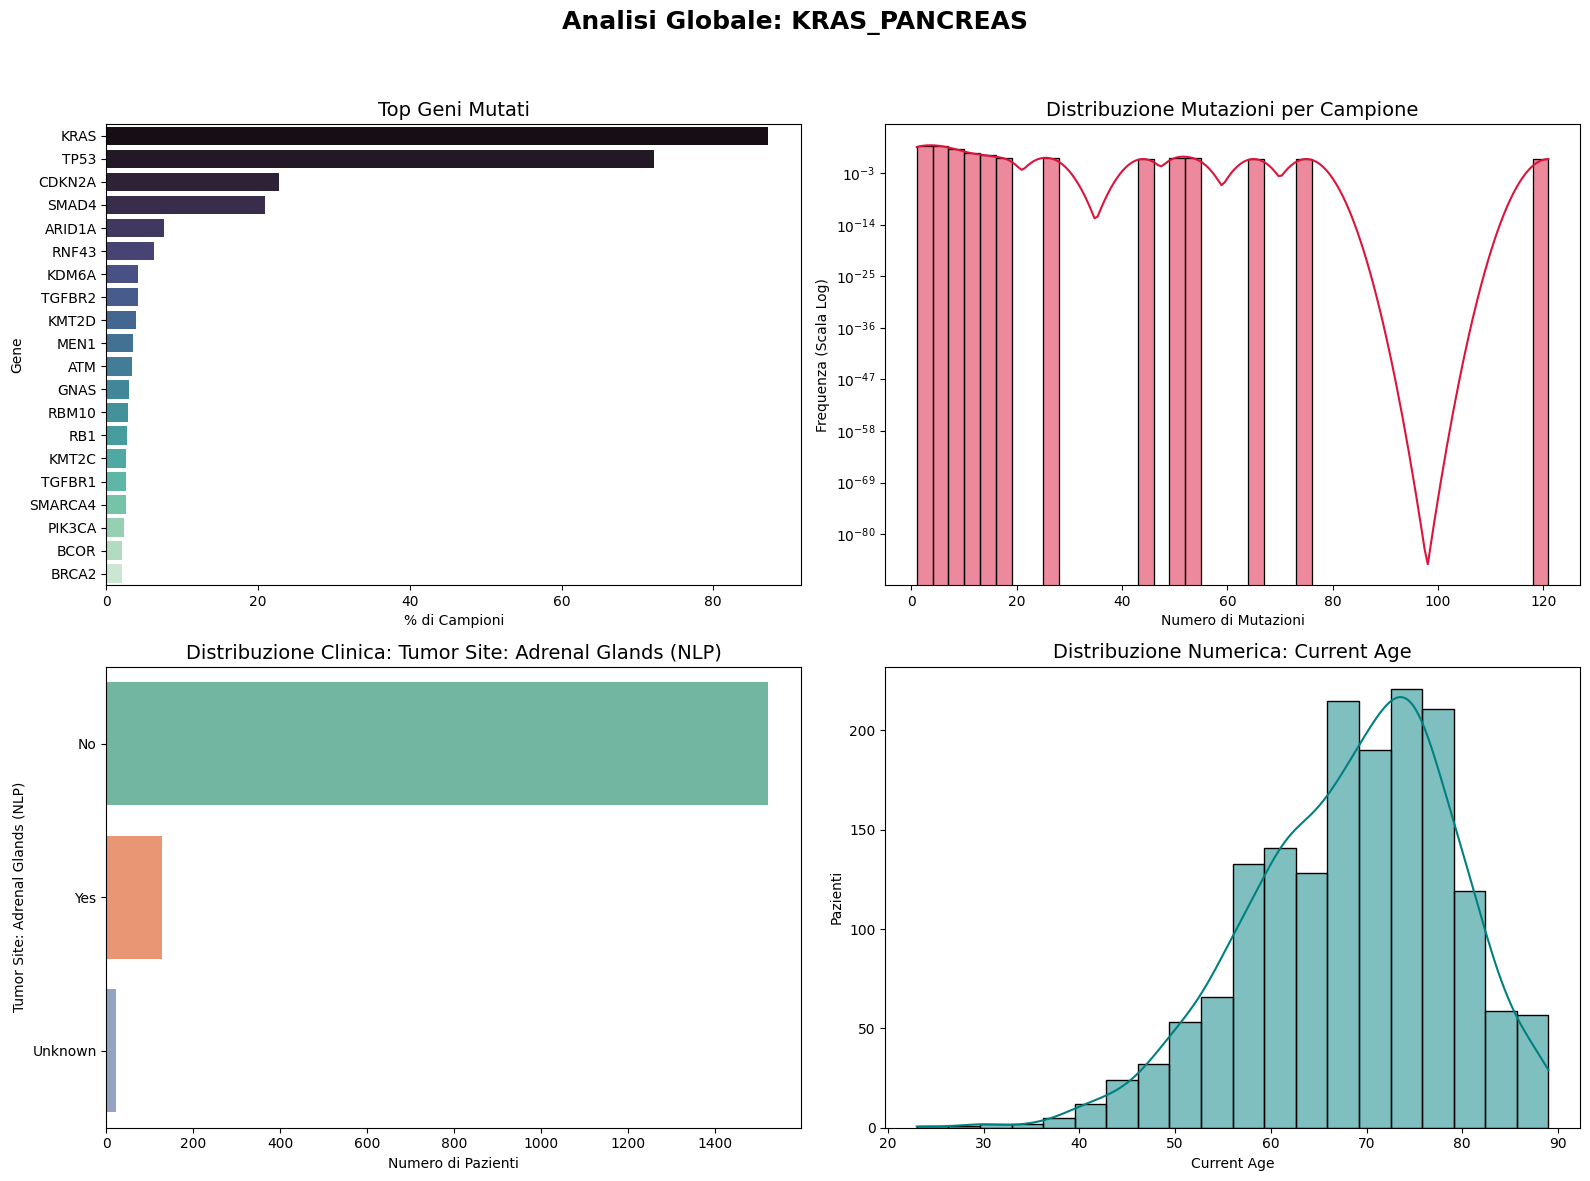

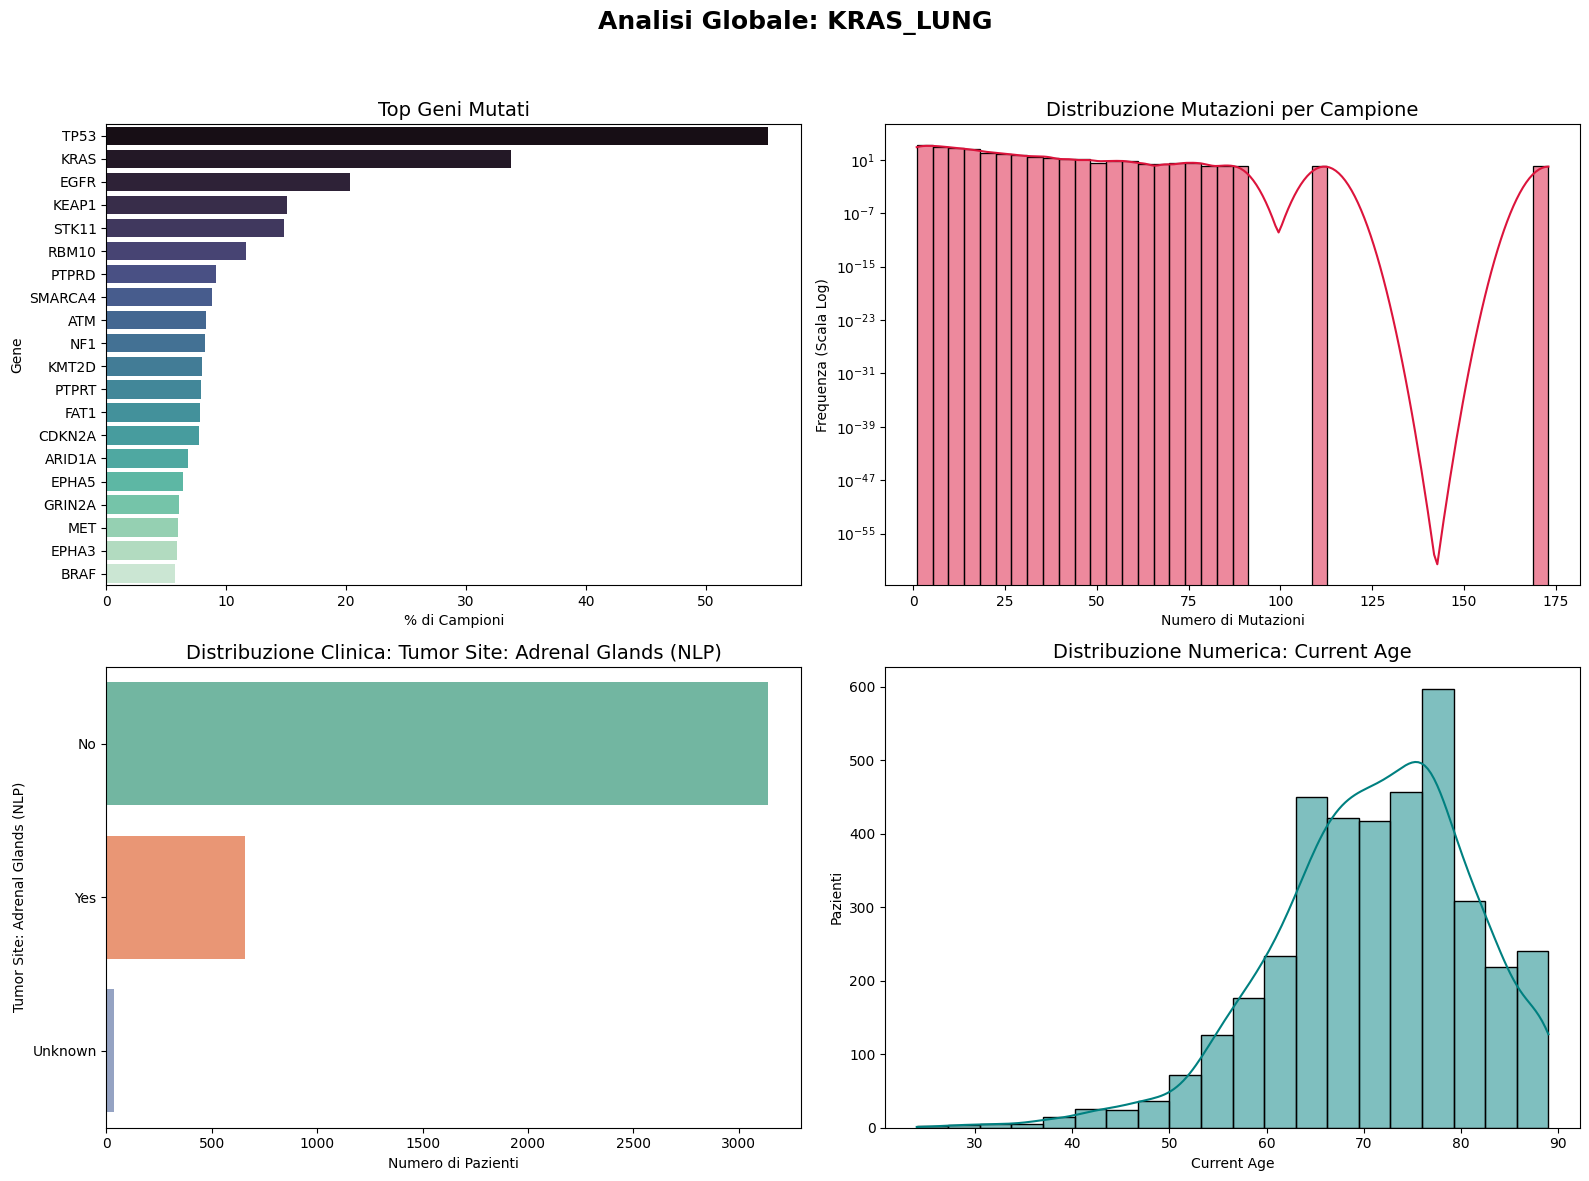

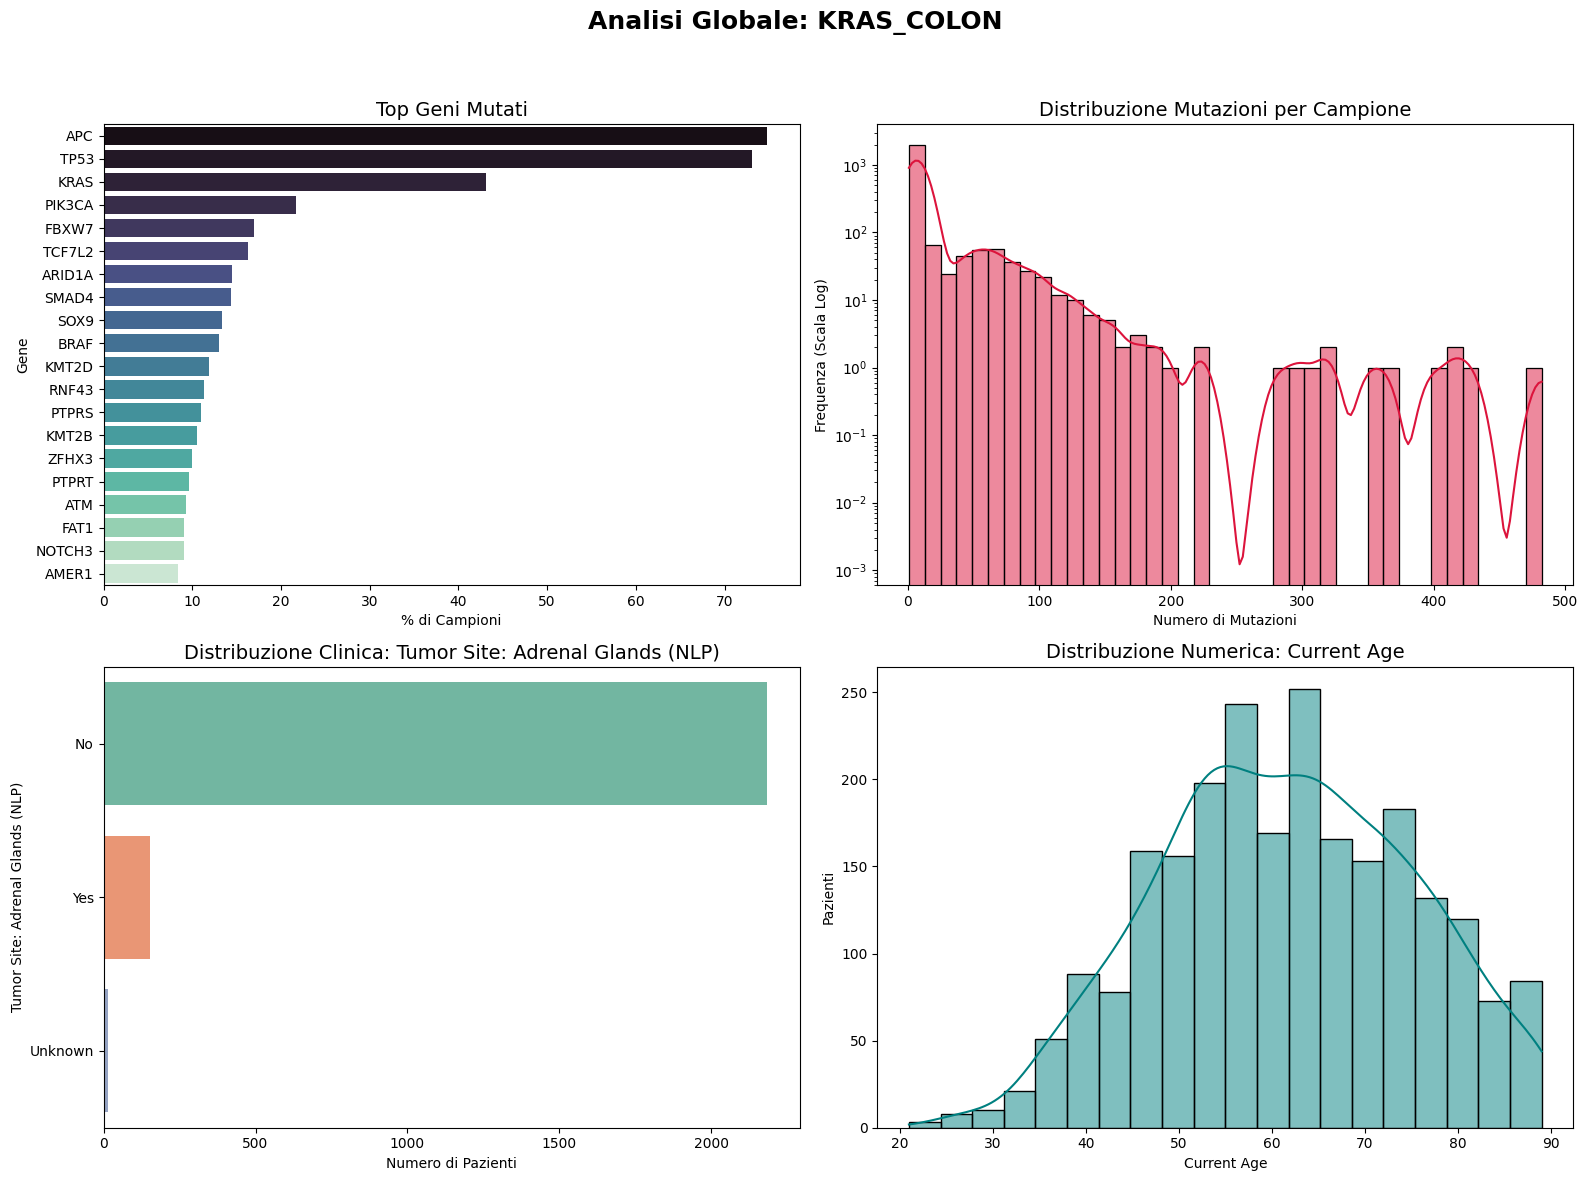

In [9]:
# --- ESECUZIONE ANALISI E GENERAZIONE PLOT ---

plot_results = []

# Analisi Pancreas
res_pancreas = analyze_cohort_stats(
    cohort_path="./kras_pancreas",
    master_filename="F_pancreas.csv",
    mut_filename="F_data_mutations.txt", 
    cna_filename="F_data_cna.txt"
)
plot_results.append(res_pancreas)

# Analisi Lung
res_lung = analyze_cohort_stats(
    cohort_path="./kras_lung",
    master_filename="F_lung.csv",
    mut_filename="F_data_mutations.txt", 
    cna_filename="F_data_cna.csv"
)
plot_results.append(res_lung)

# Analisi Colon
res_colon = analyze_cohort_stats(
    cohort_path="./kras_colon",
    master_filename="F_colon.csv",
    mut_filename="F_data_mutations.txt", 
    cna_filename="F_data_cna.csv"
)
plot_results.append(res_colon)

# Generazione dei grafici finali (Mutazionali + Clinici)
print("\nGenerazione grafici in corso...")
plot_cohort_distributions(plot_results)

## Sezione MSI-MSS

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

def analyze_msi_mss(cohort_path, master_filename, mut_filename):
    """
    Cerca la colonna MSI nei dati clinici, divide i pazienti in MSI e MSS,
    e calcola le statistiche mutazionali per entrambi i gruppi.
    """
    cohort_name = os.path.basename(cohort_path.strip('/'))
    master_path = os.path.join(cohort_path, master_filename)
    mut_path = os.path.join(cohort_path, mut_filename)
    
    if not os.path.exists(master_path) or not os.path.exists(mut_path):
        return None
        
    df_clin = pd.read_csv(master_path, sep='\t')
    df_mut = pd.read_csv(mut_path, sep='\t', low_memory=False)
    
    # 1. Ricerca automatica della colonna contenente le info MSI/MSS
    msi_col = None
    for col in df_clin.columns:
        col_str = str(col).lower()
        if 'msi' in col_str or 'microsatellite' in col_str:
            msi_col = col
            break
        # Se il nome colonna non è ovvio, controlla i valori all'interno
        if df_clin[col].astype(str).str.upper().isin(['MSI', 'MSS', 'MSI-H', 'MSI-L']).any():
            msi_col = col
            break
            
    if msi_col is None:
        print(f"\n[{cohort_name.upper()}] Nessuna colonna MSI/MSS identificata nei dati clinici.")
        return None
        
    print(f"\n" + "="*60)
    print(f"🧬 ANALISI MSI vs MSS: {cohort_name.upper()} (Trovato in colonna: '{msi_col}')")
    print(f"="*60)
    
    # 2. Funzione per standardizzare le etichette (raggruppa MSI-H, MSI-L in MSI)
    def categorize_msi(val):
        val_str = str(val).upper()
        if 'MSS' in val_str or 'STABLE' in val_str: return 'MSS'
        if 'MSI' in val_str or 'INSTABILITY' in val_str or 'INSTABLE' in val_str: return 'MSI'
        return 'Altro/Ignoto'
        
    df_clin['MSI_Group'] = df_clin[msi_col].apply(categorize_msi)
    
    # 3. Estrazione ID pazienti
    msi_ids = df_clin[df_clin['MSI_Group'] == 'MSI']['Sample_Id'].unique()
    mss_ids = df_clin[df_clin['MSI_Group'] == 'MSS']['Sample_Id'].unique()
    
    # 4. Subset delle mutazioni
    mut_msi = df_mut[df_mut['Sample_Id'].isin(msi_ids)]
    mut_mss = df_mut[df_mut['Sample_Id'].isin(mss_ids)]
    
    # --- STATISTICHE MSI ---
    msi_counts = mut_msi['Sample_Id'].value_counts() if not mut_msi.empty else pd.Series(dtype=int)
    print(f"\n🔴 GRUPPO MSI (Microsatellite Instability)")
    print(f"   • Pazienti identificati: {len(msi_ids)}")
    if not msi_counts.empty:
        print(f"   • Geni unici mutati: {mut_msi['Hugo_Symbol'].nunique()}")
        print(f"   • Mutazioni totali: {len(mut_msi)}")
        print(f"   • Mutazioni/Paziente -> Media: {msi_counts.mean():.1f} | Mediana: {msi_counts.median():.1f}")
        print(f"   • Min/Max: {msi_counts.min()} - {msi_counts.max()}")
    else:
        print("   • Nessuna mutazione trovata per questi pazienti.")

    # --- STATISTICHE MSS ---
    mss_counts = mut_mss['Sample_Id'].value_counts() if not mut_mss.empty else pd.Series(dtype=int)
    print(f"\n🔵 GRUPPO MSS (Microsatellite Stable)")
    print(f"   • Pazienti identificati: {len(mss_ids)}")
    if not mss_counts.empty:
        print(f"   • Geni unici mutati: {mut_mss['Hugo_Symbol'].nunique()}")
        print(f"   • Mutazioni totali: {len(mut_mss)}")
        print(f"   • Mutazioni/Paziente -> Media: {mss_counts.mean():.1f} | Mediana: {mss_counts.median():.1f}")
        print(f"   • Min/Max: {mss_counts.min()} - {mss_counts.max()}")
    else:
        print("   • Nessuna mutazione trovata per questi pazienti.")
        
    return cohort_name, msi_counts, mss_counts

def plot_msi_comparison(msi_results_list):
    """Crea un Boxplot per comparare visivamente il carico mutazionale tra MSI e MSS."""
    valid_results = [res for res in msi_results_list if res is not None]
    if not valid_results:
        return
        
    fig, axes = plt.subplots(1, len(valid_results), figsize=(6 * len(valid_results), 6), squeeze=False)
    
    for idx, (cohort_name, msi_counts, mss_counts) in enumerate(valid_results):
        ax = axes[0][idx]
        
        # Prepariamo i dati per il boxplot di Seaborn
        data = []
        for val in msi_counts: data.append({'Status': 'MSI', 'Mutations': val})
        for val in mss_counts: data.append({'Status': 'MSS', 'Mutations': val})
        
        if data:
            df_plot = pd.DataFrame(data)
            # Usiamo un boxplot con scala logaritmica perché i MSI sballano i grafici lineari
            sns.boxplot(x='Status', y='Mutations', data=df_plot, ax=ax, palette={'MSI': '#e74c3c', 'MSS': '#3498db'}, order=['MSS', 'MSI'])
            sns.stripplot(x='Status', y='Mutations', data=df_plot, ax=ax, color='black', alpha=0.3, jitter=True, order=['MSS', 'MSI'])
            
            ax.set_yscale('log')
            ax.set_title(f"{cohort_name.upper()}: Carico Mutazionale", fontsize=14)
            ax.set_ylabel("Numero di Mutazioni (Scala Log)")
            ax.set_xlabel("Stato Microsatellitare")
        else:
            ax.text(0.5, 0.5, 'Dati non sufficienti per il plot', ha='center', va='center')
            ax.set_title(cohort_name.upper())

    plt.tight_layout()
    plt.show()


🧬 ANALISI MSI vs MSS: KRAS_PANCREAS (Trovato in colonna: 'MSI Comment')

🔴 GRUPPO MSI (Microsatellite Instability)
   • Pazienti identificati: 33
   • Geni unici mutati: 223
   • Mutazioni totali: 486
   • Mutazioni/Paziente -> Media: 14.7 | Mediana: 4.0
   • Min/Max: 1 - 75

🔵 GRUPPO MSS (Microsatellite Stable)
   • Pazienti identificati: 1315
   • Geni unici mutati: 442
   • Mutazioni totali: 5501
   • Mutazioni/Paziente -> Media: 4.3 | Mediana: 4.0
   • Min/Max: 1 - 121

🧬 ANALISI MSI vs MSS: KRAS_LUNG (Trovato in colonna: 'MSI Comment')

🔴 GRUPPO MSI (Microsatellite Instability)
   • Pazienti identificati: 97
   • Geni unici mutati: 373
   • Mutazioni totali: 1471
   • Mutazioni/Paziente -> Media: 15.2 | Mediana: 11.0
   • Min/Max: 3 - 72

🔵 GRUPPO MSS (Microsatellite Stable)
   • Pazienti identificati: 2882
   • Geni unici mutati: 513
   • Mutazioni totali: 25734
   • Mutazioni/Paziente -> Media: 9.3 | Mediana: 7.0
   • Min/Max: 1 - 173

🧬 ANALISI MSI vs MSS: KRAS_COLON (Trovato 

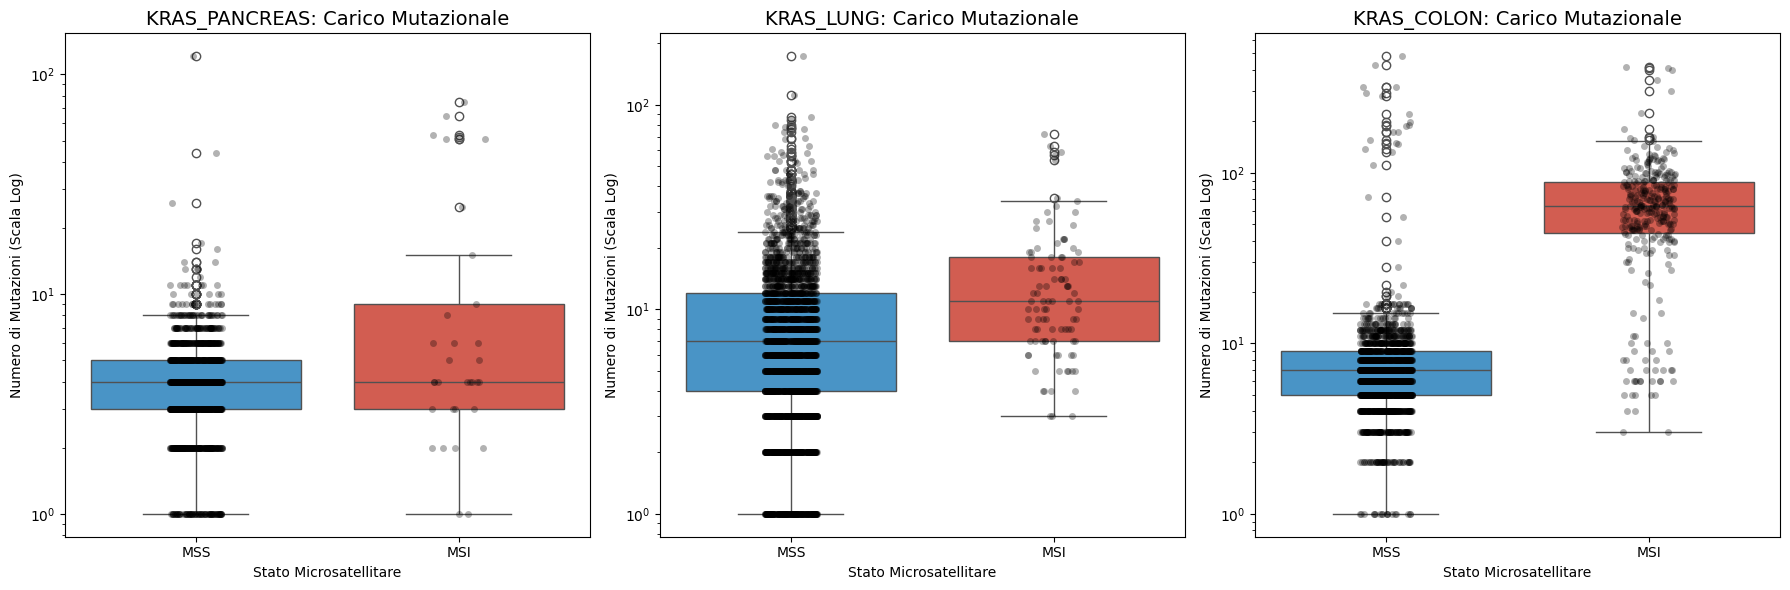

In [11]:
# --- ESECUZIONE ANALISI MSI/MSS ---

msi_results = []

# Analisi Pancreas
res_panc = analyze_msi_mss(
    cohort_path="./kras_pancreas",
    master_filename="F_pancreas.csv",
    mut_filename="F_data_mutations.txt"
)
msi_results.append(res_panc)

# Analisi Lung
res_lung = analyze_msi_mss(
    cohort_path="./kras_lung",
    master_filename="F_lung.csv",
    mut_filename="F_data_mutations.txt"
)
msi_results.append(res_lung)

# Analisi Colon (Qui ti aspetterai i risultati più marcati)
res_colon = analyze_msi_mss(
    cohort_path="./kras_colon",
    master_filename="F_colon.csv",
    mut_filename="F_data_mutations.txt"
)
msi_results.append(res_colon)

# Grafico delle distribuzioni a confronto
print("\nGenerazione Boxplot comparativi in corso...")
plot_msi_comparison(msi_results)

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

def analyze_cna(cohort_path, cna_filename, top_n=15):
    """
    Analizza i file CNA assumendo il formato standard (Hugo_Symbol come prima colonna,
    Sample ID come colonne successive) e valori discreti (-2, -1, 0, 1, 2).
    """
    cohort_name = os.path.basename(cohort_path.strip('/'))
    
    # Gestione dinamica estensione (txt/csv)
    cna_path_csv = os.path.join(cohort_path, cna_filename.replace('.txt', '.csv'))
    cna_path_txt = os.path.join(cohort_path, cna_filename.replace('.csv', '.txt'))
    cna_path = cna_path_csv if os.path.exists(cna_path_csv) else cna_path_txt
    
    if not os.path.exists(cna_path):
        print(f"File CNA non trovato per {cohort_name}")
        return None
        
    print(f"\n" + "="*60)
    print(f"🧬 ANALISI CNA (Copy Number Alterations): {cohort_name.upper()}")
    print(f"="*60)
    
    df_cna = pd.read_csv(cna_path, sep='\t')
    
    if 'Hugo_Symbol' not in df_cna.columns:
        print("Colonna 'Hugo_Symbol' mancante, analisi saltata.")
        return None
        
    # Impostiamo Hugo_Symbol come indice per lavorare solo con la matrice numerica
    df_numeric = df_cna.set_index('Hugo_Symbol')
    
    # Per le analisi di network robuste, di solito si filtrano solo le alterazioni severe
    # +2 (Amplificazioni) e -2 (Delezioni Profonde)
    
    # 1. Trova le alterazioni
    is_amp = (df_numeric >= 2)
    is_del = (df_numeric <= -2)
    is_altered = is_amp | is_del # Maschera logica per qualsiasi alterazione severa
    
    total_samples = len(df_numeric.columns)
    
    # 2. Calcolo "CNA Burden" per paziente (Quanti geni ha alterati?)
    cna_burden = is_altered.sum(axis=0) # Somma per colonna (paziente)
    
    # 3. Top Geni Amplificati
    amp_per_gene = is_amp.sum(axis=1) # Somma per riga (gene)
    top_amp = amp_per_gene.sort_values(ascending=False).head(top_n)
    top_amp = top_amp[top_amp > 0] # Scarta i geni con 0 amplificazioni
    
    # 4. Top Geni Deleti
    del_per_gene = is_del.sum(axis=1)
    top_del = del_per_gene.sort_values(ascending=False).head(top_n)
    top_del = top_del[top_del > 0]
    
    print(f"• Geni totali nella matrice CNA: {len(df_numeric)}")
    print(f"• Campioni processati: {total_samples}")
    print(f"• Media geni severamente alterati (+2/-2) per paziente: {cna_burden.mean():.1f}")
    print(f"• Mediana geni severamente alterati: {cna_burden.median():.1f}")
    
    # Percentile per identificare pazienti con alta instabilità (CIN)
    cin_75th = cna_burden.quantile(0.75)
    print(f"• Soglia alta instabilità (75° perc.): > {cin_75th:.0f} geni alterati")
    
    return cohort_name, top_amp, top_del, cna_burden, total_samples

def plot_cna_results(cna_results_list):
    """Genera 3 grafici per coorte: Top Amp, Top Del, e Distribuzione CNA Burden."""
    valid_results = [r for r in cna_results_list if r is not None]
    if not valid_results: return
    
    n_cohorts = len(valid_results)
    fig, axes = plt.subplots(n_cohorts, 3, figsize=(18, 5 * n_cohorts))
    
    # Gestione corretta dell'array di assi se c'è solo una coorte
    if n_cohorts == 1: axes = [axes]
    
    for idx, (cohort_name, top_amp, top_del, cna_burden, total_samples) in enumerate(valid_results):
        
        # Grafico 1: Top Amplificazioni (+2)
        ax1 = axes[idx][0]
        if not top_amp.empty:
            perc_amp = (top_amp / total_samples) * 100
            sns.barplot(x=perc_amp.values, y=perc_amp.index, ax=ax1, palette="Reds_r")
            ax1.set_title(f"{cohort_name.upper()}: Top Amplificazioni (+2)", fontsize=13)
            ax1.set_xlabel("% di Pazienti")
        else:
            ax1.text(0.5, 0.5, "Nessuna Amplificazione trovata", ha='center')
            
        # Grafico 2: Top Delezioni (-2)
        ax2 = axes[idx][1]
        if not top_del.empty:
            perc_del = (top_del / total_samples) * 100
            sns.barplot(x=perc_del.values, y=perc_del.index, ax=ax2, palette="Blues_r")
            ax2.set_title(f"{cohort_name.upper()}: Top Delezioni Profonde (-2)", fontsize=13)
            ax2.set_xlabel("% di Pazienti")
        else:
            ax2.text(0.5, 0.5, "Nessuna Delezione trovata", ha='center')
            
        # Grafico 3: Distribuzione CNA Burden (Instabilità Genomica)
        ax3 = axes[idx][2]
        sns.histplot(cna_burden, bins=40, kde=True, ax=ax3, color="purple", alpha=0.6)
        ax3.set_title(f"{cohort_name.upper()}: CNA Burden per Paziente", fontsize=13)
        ax3.set_xlabel("Numero di Geni Alterati (+2 / -2)")
        ax3.set_ylabel("Frequenza")
        # Niente scala log qui, le distribuzioni CNA tendono a essere bimodali o continue
        
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()


🧬 ANALISI CNA (Copy Number Alterations): KRAS_PANCREAS
• Geni totali nella matrice CNA: 702
• Campioni processati: 1669
• Media geni severamente alterati (+2/-2) per paziente: 1.5
• Mediana geni severamente alterati: 0.0
• Soglia alta instabilità (75° perc.): > 2 geni alterati

🧬 ANALISI CNA (Copy Number Alterations): KRAS_LUNG
• Geni totali nella matrice CNA: 702
• Campioni processati: 3833
• Media geni severamente alterati (+2/-2) per paziente: 2.3
• Mediana geni severamente alterati: 0.0
• Soglia alta instabilità (75° perc.): > 3 geni alterati

🧬 ANALISI CNA (Copy Number Alterations): KRAS_COLON
• Geni totali nella matrice CNA: 702
• Campioni processati: 2346
• Media geni severamente alterati (+2/-2) per paziente: 1.6
• Mediana geni severamente alterati: 0.0
• Soglia alta instabilità (75° perc.): > 2 geni alterati

Generazione grafici CNA in corso...


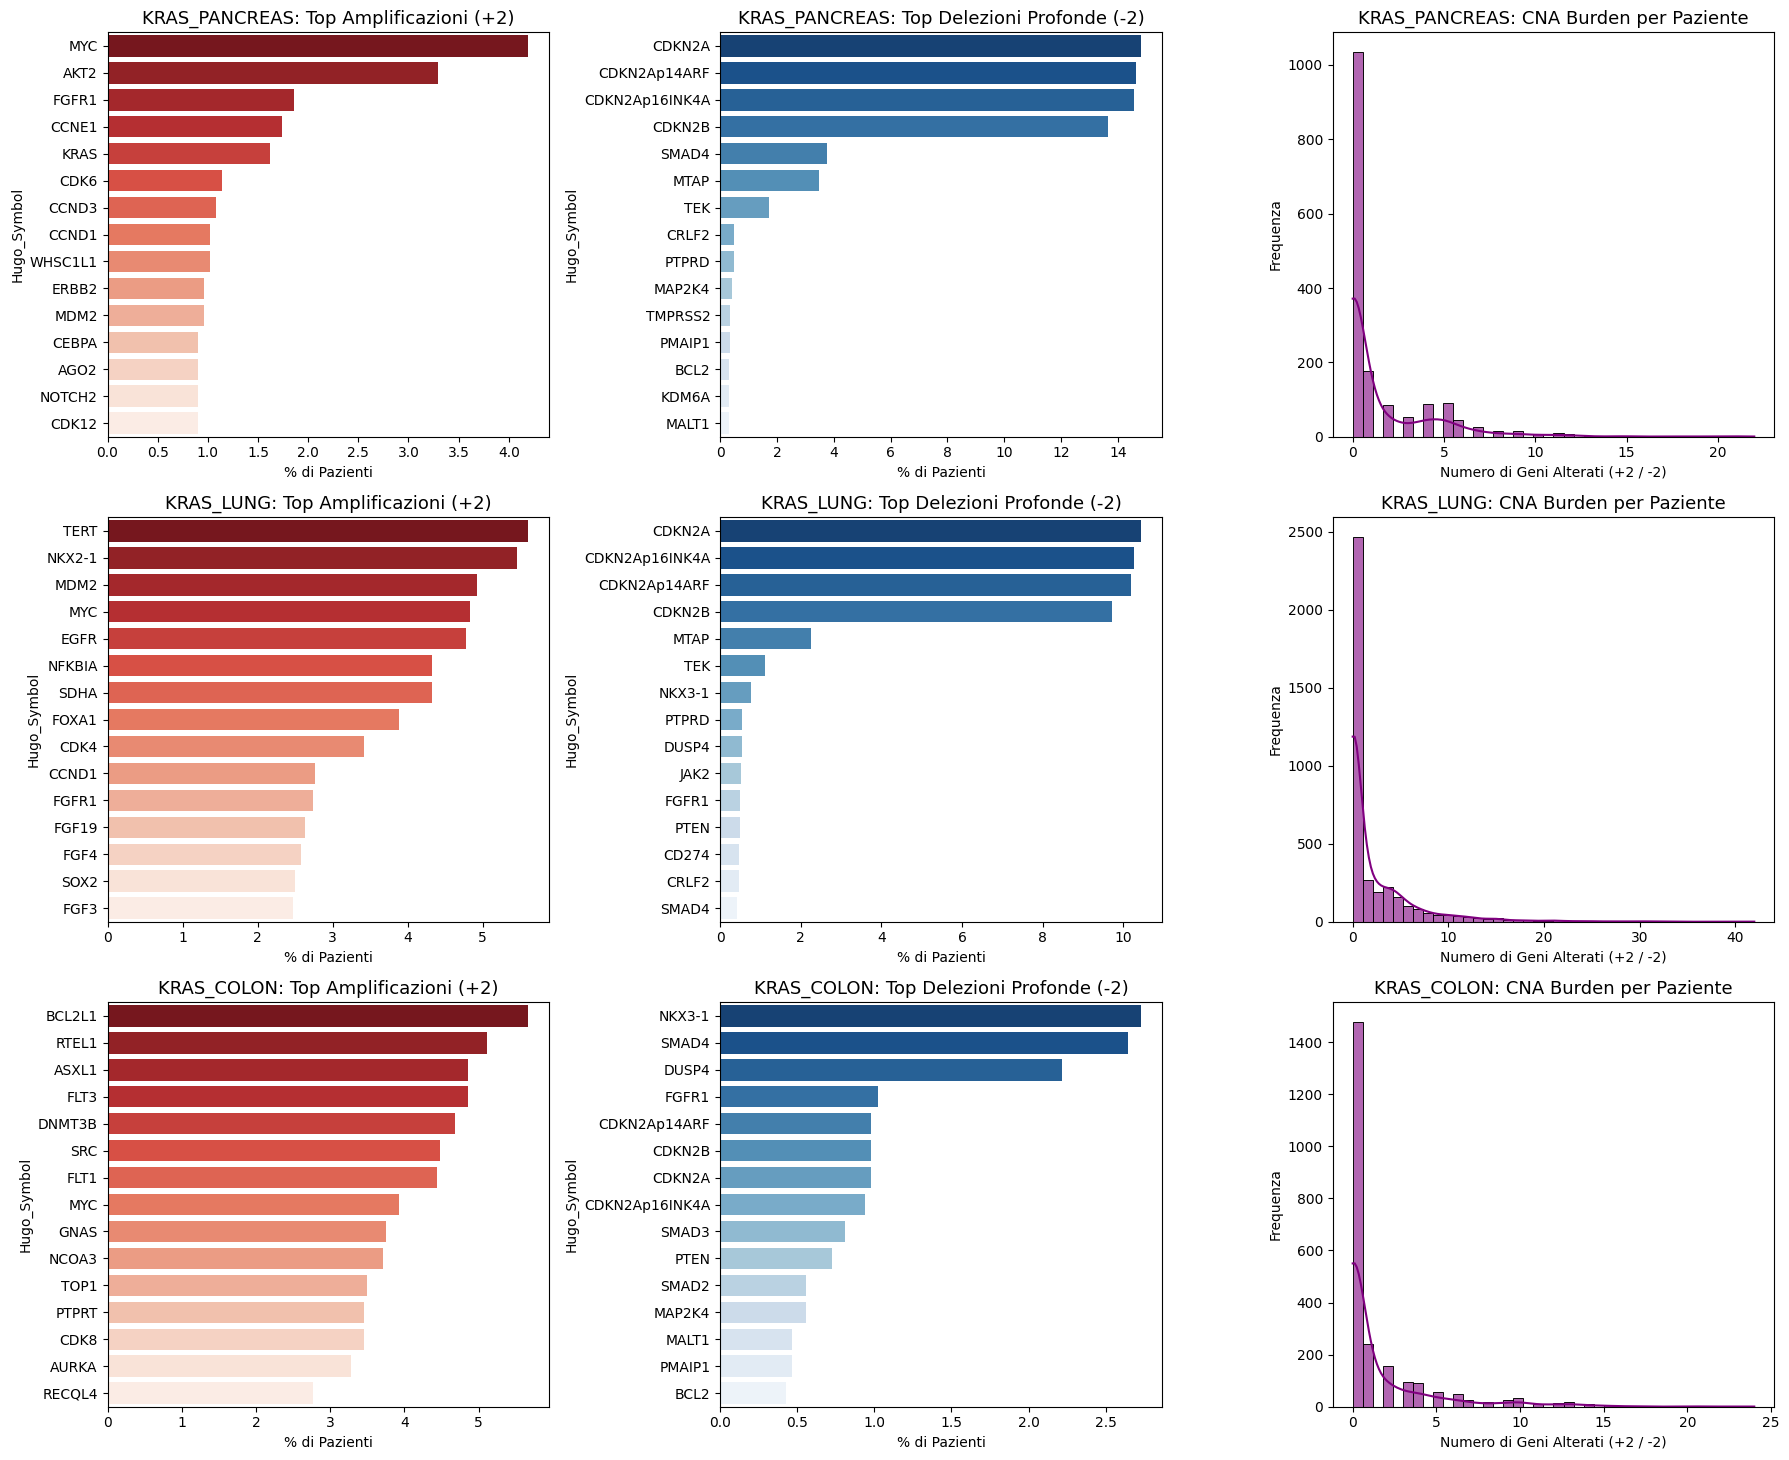

In [13]:
# --- ESECUZIONE ANALISI CNA SULLE COORTI ---
cna_results = []

# Analisi Pancreas
res_cna_panc = analyze_cna(
    cohort_path="./kras_pancreas",
    cna_filename="F_data_cna.txt"
)
cna_results.append(res_cna_panc)

# Analisi Lung
res_cna_lung = analyze_cna(
    cohort_path="./kras_lung",
    cna_filename="F_data_cna.csv"
)
cna_results.append(res_cna_lung)

# Analisi Colon
res_cna_colon = analyze_cna(
    cohort_path="./kras_colon",
    cna_filename="F_data_cna.csv"
)
cna_results.append(res_cna_colon)

# Generazione dei grafici specifici per Copy Number
print("\nGenerazione grafici CNA in corso...")
plot_cna_results(cna_results)

## Analisi per sotto tipi

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

warnings.filterwarnings('ignore')

def analyze_subtypes_comprehensive(cohort_path, master_filename, mut_filename, cna_filename, min_patients=3, target_col="Cancer Type Detailed"):
    """
    Esegue un'analisi integrata raggruppata per la colonna specificata.
    Include le statistiche dettagliate (min, max, media, mediana) per i gruppi MSI e MSS.
    """
    cohort_name = os.path.basename(cohort_path.strip('/'))
    print(f"\n" + "="*80)
    print(f"🔬 ANALISI PER SOTTOTIPO ({target_col}): {cohort_name.upper()}")
    print(f"="*80)
    
    master_path = os.path.join(cohort_path, master_filename)
    mut_path = os.path.join(cohort_path, mut_filename)
    cna_path_csv = os.path.join(cohort_path, cna_filename.replace('.txt', '.csv'))
    cna_path_txt = os.path.join(cohort_path, cna_filename.replace('.csv', '.txt'))
    cna_path = cna_path_csv if os.path.exists(cna_path_csv) else cna_path_txt
    
    if not os.path.exists(master_path):
        print(f"File clinico mancante per {cohort_name}.")
        return None
        
    df_clin = pd.read_csv(master_path, sep='\t')
    
    # 1. Identificazione colonna Sottotipo
    subtype_col = None
    for col in df_clin.columns:
        if col.strip().lower() == target_col.strip().lower():
            subtype_col = col
            break
            
    if subtype_col is None:
        print(f"❌ Errore: Colonna '{target_col}' non trovata. Colonne disponibili: {list(df_clin.columns[:10])}...")
        return None

    # 2. Identificazione colonna MSI
    msi_col = None
    for col in df_clin.columns:
        col_str = str(col).lower()
        if 'msi' in col_str or 'microsatellite' in col_str:
            msi_col = col
            break
        if df_clin[col].astype(str).str.upper().isin(['MSI', 'MSS', 'MSI-H', 'MSI-L']).any():
            msi_col = col
            break
            
    def categorize_msi(val):
        val_str = str(val).upper()
        if 'MSS' in val_str or 'STABLE' in val_str: return 'MSS'
        if 'MSI' in val_str or 'INSTABILITY' in val_str or 'INSTABLE' in val_str: return 'MSI'
        return 'Ignoto/Altro'

    if msi_col:
        df_clin['MSI_Group'] = df_clin[msi_col].apply(categorize_msi)
    else:
        df_clin['MSI_Group'] = 'Ignoto'

    # 3. Estrazione TMB (Mutazioni)
    if os.path.exists(mut_path):
        df_mut = pd.read_csv(mut_path, sep='\t', low_memory=False)
        tmb_counts = df_mut['Sample_Id'].value_counts().rename('TMB')
        df_clin = df_clin.merge(tmb_counts, left_on='Sample_Id', right_index=True, how='left')
        df_clin['TMB'] = df_clin['TMB'].fillna(0)
    else:
        df_clin['TMB'] = np.nan

    # 4. Estrazione CNA Burden
    if os.path.exists(cna_path):
        df_cna = pd.read_csv(cna_path, sep='\t')
        if 'Hugo_Symbol' in df_cna.columns:
            df_numeric = df_cna.set_index('Hugo_Symbol')
            is_altered = (df_numeric >= 2) | (df_numeric <= -2)
            cna_burden = is_altered.sum(axis=0).rename('CNA_Burden')
            df_clin = df_clin.merge(cna_burden, left_on='Sample_Id', right_index=True, how='left')
            df_clin['CNA_Burden'] = df_clin['CNA_Burden'].fillna(0)
        else:
            df_clin['CNA_Burden'] = np.nan
    else:
        df_clin['CNA_Burden'] = np.nan

    # 5. Filtraggio sottotipi rari
    subtype_counts = df_clin[subtype_col].value_counts()
    valid_subtypes = subtype_counts[subtype_counts >= min_patients].index
    df_filtered = df_clin[df_clin[subtype_col].isin(valid_subtypes)]
    
    # Stampa Recap Statistiche Dettagliate
    for st in valid_subtypes:
        st_data = df_filtered[df_filtered[subtype_col] == st]
        print(f"\n▶ SOTTOTIPO: {st} (Pazienti totali: {len(st_data)})")
        
        # Statistiche di gruppo MSI vs MSS
        if msi_col:
            for status in ['MSS', 'MSI']:
                subset = st_data[st_data['MSI_Group'] == status]
                if not subset.empty:
                    print(f"  [{status}] Pazienti: {len(subset)}")
                    print(f"        TMB -> Mediana: {subset['TMB'].median():.1f} | Media: {subset['TMB'].mean():.1f} | Min: {subset['TMB'].min():.0f} | Max: {subset['TMB'].max():.0f}")
                    if not subset['CNA_Burden'].isna().all():
                        print(f"        CNA -> Mediana: {subset['CNA_Burden'].median():.1f} | Media: {subset['CNA_Burden'].mean():.1f} | Min: {subset['CNA_Burden'].min():.0f} | Max: {subset['CNA_Burden'].max():.0f}")
                else:
                    print(f"  [{status}] Nessun paziente in questa categoria.")
        else:
            print(f"  - TMB Globale -> Mediana: {st_data['TMB'].median():.1f} | Media: {st_data['TMB'].mean():.1f}")

    return cohort_name, df_filtered, subtype_col


def plot_subtype_dashboard(results_list):
    """Genera una dashboard con 6 grafici integrati per coorte."""
    valid_results = [r for r in results_list if r is not None]
    if not valid_results: return
    
    for cohort_name, df_clin, subtype_col in valid_results:
        # Struttura 3 righe x 2 colonne per far spazio ai nuovi grafici
        fig = plt.figure(figsize=(18, 18)) 
        fig.suptitle(f"Profilo Genomico Avanzato per '{subtype_col}': {cohort_name.upper()}", fontsize=20, fontweight='bold', y=0.98)
        
        # Ordiniamo i sottotipi per TMB mediano globale
        order = df_clin.groupby(subtype_col)['TMB'].median().sort_values(ascending=False).index
        
        # --- 1. TMB Globale per Sottotipo ---
        ax1 = plt.subplot(3, 2, 1)
        sns.boxplot(y=subtype_col, x='TMB', data=df_clin, order=order, ax=ax1, palette="mako", showfliers=False)
        sns.stripplot(y=subtype_col, x='TMB', data=df_clin, order=order, ax=ax1, color='black', alpha=0.3, jitter=True)
        ax1.set_xscale('log')
        ax1.set_title("1. Tumor Mutational Burden (TMB Globale)", fontsize=14)
        ax1.set_xlabel("Numero Mutazioni (Log)")
        ax1.set_ylabel("")
        
        # --- 2. CNA Burden per Sottotipo ---
        ax2 = plt.subplot(3, 2, 2)
        if not df_clin['CNA_Burden'].isna().all():
            sns.boxplot(y=subtype_col, x='CNA_Burden', data=df_clin, order=order, ax=ax2, palette="flare", showfliers=False)
            sns.stripplot(y=subtype_col, x='CNA_Burden', data=df_clin, order=order, ax=ax2, color='black', alpha=0.3, jitter=True)
            ax2.set_title("2. Instabilità Cromosomica (CNA Burden)", fontsize=14)
            ax2.set_xlabel("Numero di Geni Alterati (+2/-2)")
            ax2.set_ylabel("")
        else:
            ax2.text(0.5, 0.5, "Dati CNA non disponibili", ha='center')

        # --- 3. Prevalenza MSI/MSS ---
        ax3 = plt.subplot(3, 2, 3)
        if 'MSI_Group' in df_clin.columns and (df_clin['MSI_Group'] != 'Ignoto/Altro').any():
            crosstab = pd.crosstab(df_clin[subtype_col], df_clin['MSI_Group'], normalize='index') * 100
            crosstab = crosstab.reindex(order) 
            
            colors = []
            for col in crosstab.columns:
                if col == 'MSI': colors.append('#e74c3c')
                elif col == 'MSS': colors.append('#3498db')
                else: colors.append('#95a5a6')
                
            crosstab.plot(kind='barh', stacked=True, ax=ax3, color=colors, width=0.8)
            ax3.set_title("3. Prevalenza MSI vs MSS", fontsize=14)
            ax3.set_xlabel("Percentuale (%)")
            ax3.set_ylabel("")
            ax3.legend(title="Stato", loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)
        else:
            ax3.text(0.5, 0.5, "Dati MSI non disponibili", ha='center')

        # --- 4. Conteggio Campioni ---
        ax4 = plt.subplot(3, 2, 4)
        sns.countplot(y=subtype_col, data=df_clin, order=order, ax=ax4, palette="crest")
        ax4.set_title("4. Numerosità del Campione", fontsize=14)
        ax4.set_xlabel("Numero di Pazienti")
        ax4.set_ylabel("")

        # --- 5. TMB Sdoppiato per MSI e MSS (Statistiche Visive) ---
        ax5 = plt.subplot(3, 2, 5)
        df_valid_msi = df_clin[df_clin['MSI_Group'].isin(['MSI', 'MSS'])]
        if not df_valid_msi.empty:
            # Boxplot diviso per colore (hue)
            sns.boxplot(y=subtype_col, x='TMB', hue='MSI_Group', data=df_valid_msi, order=order, ax=ax5, palette={'MSI': '#e74c3c', 'MSS': '#3498db'}, showfliers=False)
            # Aggiunta dei punti singoli sfalsati (dodge=True) per matchare le scatole
            sns.stripplot(y=subtype_col, x='TMB', hue='MSI_Group', data=df_valid_msi, order=order, ax=ax5, color='black', alpha=0.4, dodge=True, legend=False)
            
            ax5.set_xscale('log')
            ax5.set_title("5. Dettaglio TMB: Sottogruppi MSI vs MSS", fontsize=14)
            ax5.set_xlabel("Numero Mutazioni (Log)")
            ax5.set_ylabel("")
            ax5.legend(title="Stato", loc='lower right')
        else:
            ax5.text(0.5, 0.5, "Dati sufficienti non disponibili", ha='center')

        # --- 6. Dicotomia Evolutiva: TMB vs CNA Burden ---
        ax6 = plt.subplot(3, 2, 6)
        if not df_clin['CNA_Burden'].isna().all() and not df_valid_msi.empty:
            sns.scatterplot(x='CNA_Burden', y='TMB', hue='MSI_Group', data=df_valid_msi, ax=ax6, palette={'MSI': '#e74c3c', 'MSS': '#3498db'}, alpha=0.7, s=70)
            ax6.set_yscale('log')
            
            # Linee guida per definire grossolanamente i quadranti
            tmb_med = df_valid_msi['TMB'].median()
            cna_med = df_valid_msi['CNA_Burden'].median()
            ax6.axhline(tmb_med, color='gray', linestyle='--', alpha=0.5)
            ax6.axvline(cna_med, color='gray', linestyle='--', alpha=0.5)
            
            ax6.set_title("6. Dicotomia Evolutiva (Mutazionale vs Cromosomica)", fontsize=14)
            ax6.set_xlabel("CNA Burden (Alterazioni Strutturali / Copy Number)")
            ax6.set_ylabel("TMB (Mutazioni Puntiformi - Log)")
            ax6.legend(title="Stato", loc='best')
        else:
            ax6.text(0.5, 0.5, "Dati CNA o MSI non disponibili", ha='center')

        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()


🔬 ANALISI PER SOTTOTIPO (Cancer Type Detailed): KRAS_PANCREAS

▶ SOTTOTIPO: Pancreatic Adenocarcinoma (Pazienti totali: 1491)
  [MSS] Pazienti: 1189
        TMB -> Mediana: 4.0 | Media: 4.2 | Min: 0 | Max: 44
        CNA -> Mediana: 0.0 | Media: 1.6 | Min: 0 | Max: 22
  [MSI] Pazienti: 20
        TMB -> Mediana: 5.5 | Media: 21.0 | Min: 2 | Max: 75
        CNA -> Mediana: 0.0 | Media: 3.0 | Min: 0 | Max: 20

▶ SOTTOTIPO: Pancreatic Neuroendocrine Tumor (Pazienti totali: 103)
  [MSS] Pazienti: 70
        TMB -> Mediana: 3.0 | Media: 4.7 | Min: 0 | Max: 121
        CNA -> Mediana: 0.0 | Media: 1.4 | Min: 0 | Max: 21
  [MSI] Pazienti: 13
        TMB -> Mediana: 4.0 | Media: 5.1 | Min: 1 | Max: 25
        CNA -> Mediana: 1.0 | Media: 3.2 | Min: 0 | Max: 20

▶ SOTTOTIPO: Adenosquamous Carcinoma of the Pancreas (Pazienti totali: 29)
  [MSS] Pazienti: 20
        TMB -> Mediana: 4.0 | Media: 4.3 | Min: 1 | Max: 6
        CNA -> Mediana: 0.0 | Media: 1.9 | Min: 0 | Max: 11
  [MSI] Nessun pazie

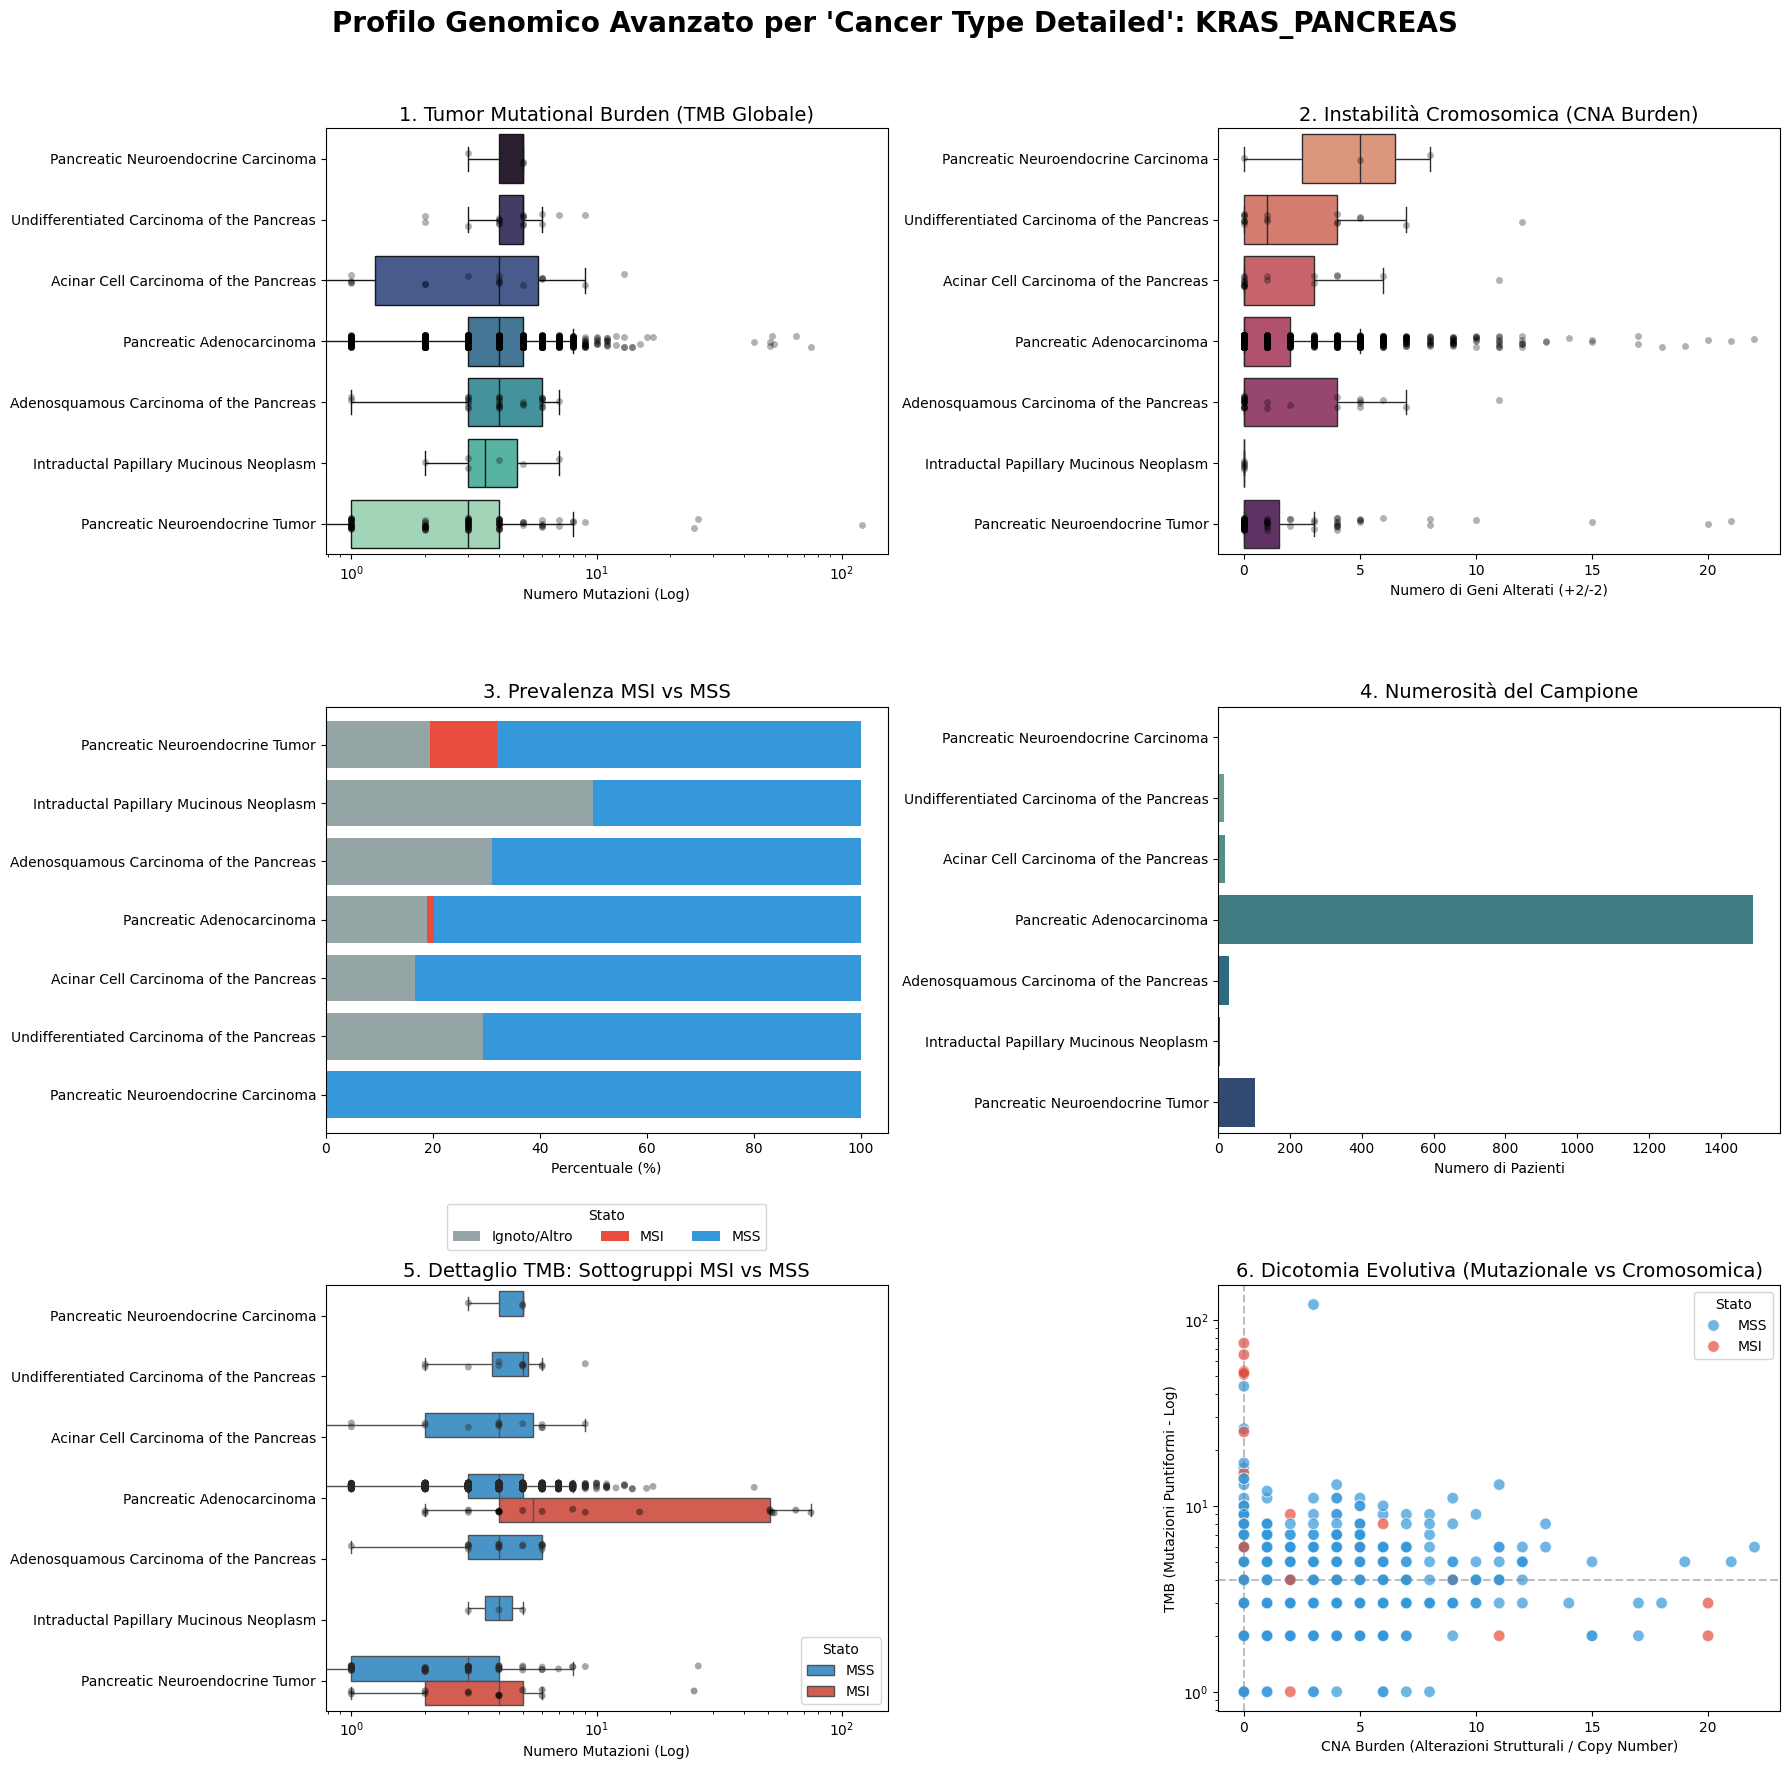

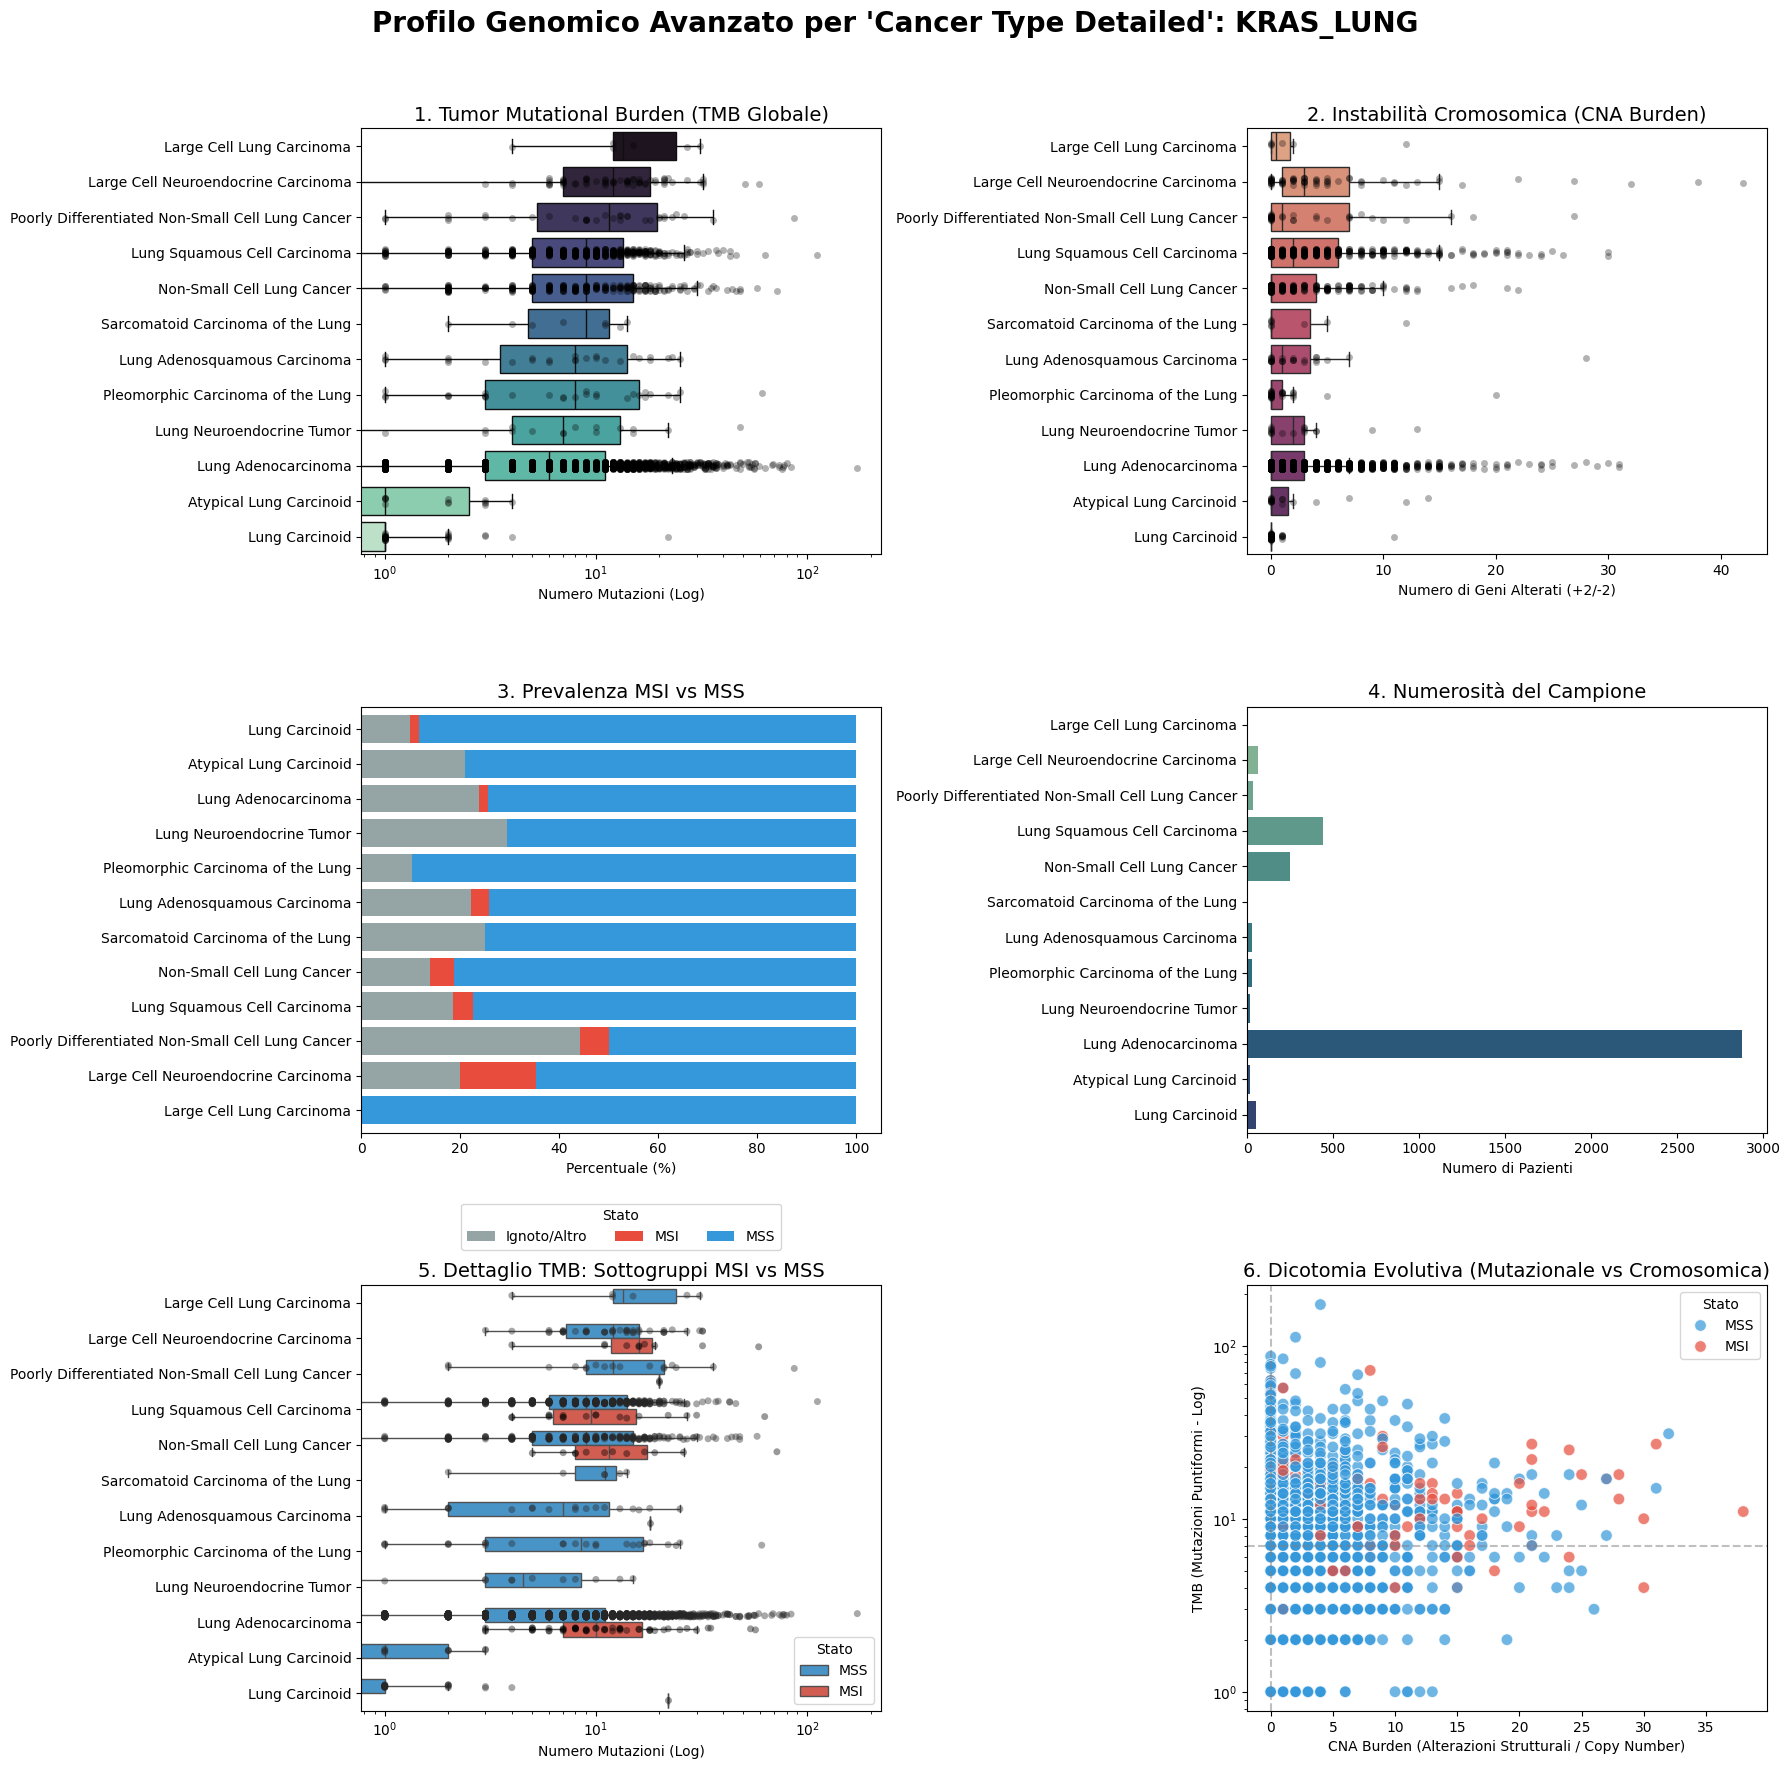

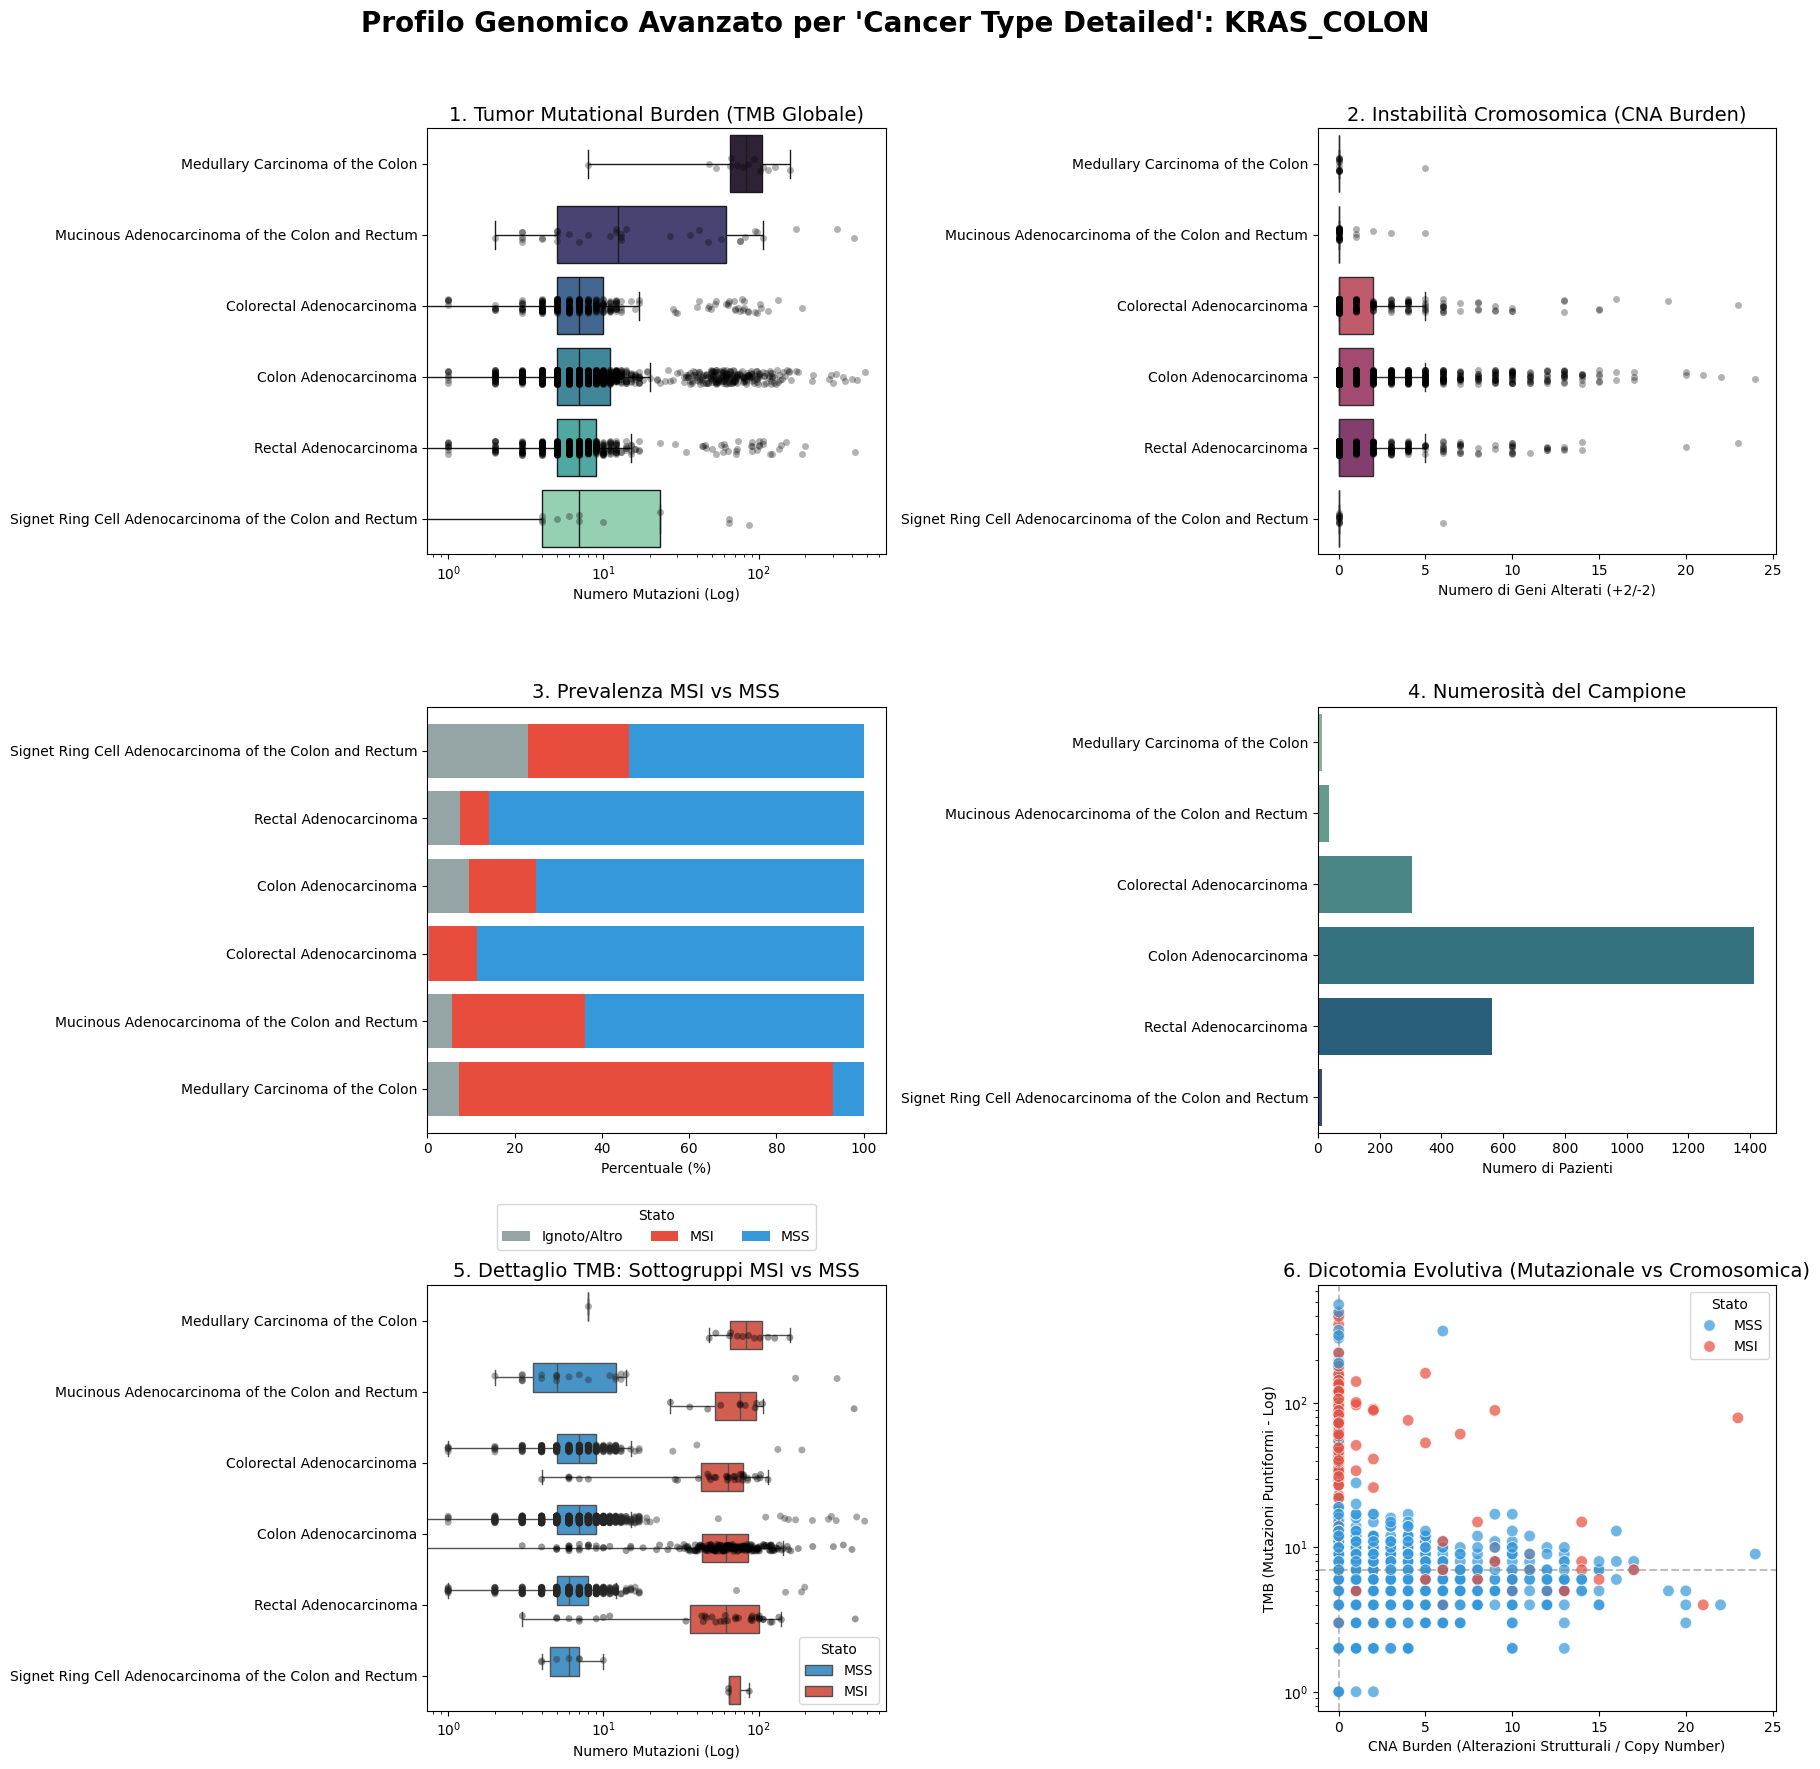

In [19]:
# --- ESECUZIONE ANALISI SOTTOTIPI ---

subtype_results = []

# Analisi Pancreas
res_panc = analyze_subtypes_comprehensive(
    cohort_path="./kras_pancreas",
    master_filename="F_pancreas.csv",
    mut_filename="F_data_mutations.txt",
    cna_filename="F_data_cna.txt"
)
subtype_results.append(res_panc)

# Analisi Lung
res_lung = analyze_subtypes_comprehensive(
    cohort_path="./kras_lung",
    master_filename="F_lung.csv",
    mut_filename="F_data_mutations.txt",
    cna_filename="F_data_cna.csv"
)
subtype_results.append(res_lung)

# Analisi Colon
res_colon = analyze_subtypes_comprehensive(
    cohort_path="./kras_colon",
    master_filename="F_colon.csv",
    mut_filename="F_data_mutations.txt",
    cna_filename="F_data_cna.csv"
)
subtype_results.append(res_colon)

# Generazione Dashboard Sottotipi
print("\nGenerazione delle Dashboard per Sottotipo in corso...")
plot_subtype_dashboard(subtype_results)

## SV

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

warnings.filterwarnings('ignore')

def analyze_structural_variants(cohort_path, master_filename, sv_filename, top_n=15, target_col="Cancer Type Detailed"):
    """
    Analizza i file delle varianti strutturali (SV/Fusioni) e calcola le statistiche.
    """
    cohort_name = os.path.basename(cohort_path.strip('/'))
    print(f"\n" + "="*80)
    print(f"🧬 ANALISI VARIANTI STRUTTURALI (SV): {cohort_name.upper()}")
    print(f"="*80)
    
    master_path = os.path.join(cohort_path, master_filename)
    # Gestione flessibile estensione file SV (potrebbe essere .txt o .csv)
    sv_path_csv = os.path.join(cohort_path, sv_filename.replace('.txt', '.csv'))
    sv_path_txt = os.path.join(cohort_path, sv_filename.replace('.csv', '.txt'))
    sv_path = sv_path_csv if os.path.exists(sv_path_csv) else sv_path_txt
    
    if not os.path.exists(sv_path):
        print(f"❌ File SV ({sv_filename}) non trovato per {cohort_name}.")
        return None
        
    df_sv = pd.read_csv(sv_path, sep='\t', low_memory=False)
    
    # 1. Identificazione dinamica delle colonne rilevanti per SV
    # Colonna del Gene (spesso Site1_Hugo_Symbol o Hugo_Symbol)
    gene_col = None
    for col in ['Site1_Hugo_Symbol', 'Hugo_Symbol', 'Gene_Symbol', 'Gene1']:
        if col in df_sv.columns:
            gene_col = col
            break
            
    # Colonna della classe/tipo di SV (es. FUSION, TRANSLOCATION)
    class_col = None
    for col in ['Class', 'SV_Class', 'Variant_Classification', 'Event_Info', 'Type']:
        if col in df_sv.columns:
            class_col = col
            break
            
    if 'Sample_Id' not in df_sv.columns or not gene_col:
        print(f"❌ Colonne essenziali mancanti nel file SV. Trovate: {list(df_sv.columns[:5])}...")
        return None

    # --- Calcoli di base SV ---
    total_svs = len(df_sv)
    unique_sv_samples = df_sv['Sample_Id'].nunique()
    
    # SV Burden (Numero di SV per paziente)
    sv_burden = df_sv['Sample_Id'].value_counts().rename('SV_Burden')
    
    # Top Geni coinvolti in SV
    top_sv_genes = df_sv[gene_col].value_counts().head(top_n)
    
    # Distribuzione delle Classi SV
    sv_classes = df_sv[class_col].value_counts() if class_col else pd.Series(dtype=int)
    
    print(f"• Eventi SV totali: {total_svs}")
    print(f"• Pazienti con almeno 1 SV: {unique_sv_samples}")
    print(f"• Media SV/Paziente: {sv_burden.mean():.2f} | Max SV in un paziente: {sv_burden.max()}")
    if class_col:
        print(f"• Tipi di SV rilevati: {list(sv_classes.index[:3])}...")

    # --- Incrocio con la clinica (Sottotipi) ---
    df_clin = pd.DataFrame()
    subtype_col = target_col
    
    if os.path.exists(master_path):
        df_clin = pd.read_csv(master_path, sep='\t')
        
        # Cerca la colonna target
        found_target = False
        for col in df_clin.columns:
            if col.strip().lower() == target_col.strip().lower():
                subtype_col = col
                found_target = True
                break
                
        if found_target:
            # Merge clinica + SV Burden
            df_clin = df_clin.merge(sv_burden, left_on='Sample_Id', right_index=True, how='left')
            df_clin['SV_Burden'] = df_clin['SV_Burden'].fillna(0) # Pazienti senza SV hanno 0
            
            # Filtra sottotipi rari per grafici più puliti (min 3 pazienti)
            subtype_counts = df_clin[subtype_col].value_counts()
            valid_subtypes = subtype_counts[subtype_counts >= 3].index
            df_clin = df_clin[df_clin[subtype_col].isin(valid_subtypes)]
        else:
            df_clin = pd.DataFrame() # Se non trova il sottotipo, annulla il merge clinico
            
    return cohort_name, top_sv_genes, sv_classes, sv_burden, df_clin, subtype_col


def plot_sv_dashboard(sv_results_list):
    """Genera una dashboard con 4 grafici dedicati alle varianti strutturali."""
    valid_results = [r for r in sv_results_list if r is not None]
    if not valid_results: return
    
    for cohort_name, top_sv_genes, sv_classes, sv_burden, df_clin, subtype_col in valid_results:
        fig = plt.figure(figsize=(18, 12)) 
        fig.suptitle(f"Profilo Varianti Strutturali (SV/Fusioni): {cohort_name.upper()}", fontsize=20, fontweight='bold', y=0.98)
        
        # --- 1. Top Geni Coinvolti ---
        ax1 = plt.subplot(2, 2, 1)
        sns.barplot(x=top_sv_genes.values, y=top_sv_genes.index, ax=ax1, palette="magma")
        ax1.set_title("1. Top Geni coinvolti in Eventi SV", fontsize=14)
        ax1.set_xlabel("Numero di Eventi Strutturali")
        ax1.set_ylabel("Gene (Site 1)")
        
        # --- 2. Distribuzione Classi SV ---
        ax2 = plt.subplot(2, 2, 2)
        if not sv_classes.empty:
            sns.barplot(x=sv_classes.values, y=sv_classes.index, ax=ax2, palette="viridis")
            ax2.set_title("2. Tipologia di Varianti Strutturali", fontsize=14)
            ax2.set_xlabel("Frequenza")
            ax2.set_ylabel("Classe (Es. Fusion, Traslocation, Deletion)")
        else:
            ax2.text(0.5, 0.5, "Colonna Classe SV non trovata", ha='center')

        # --- 3. Distribuzione SV Burden ---
        ax3 = plt.subplot(2, 2, 3)
        sns.histplot(sv_burden, bins=30, kde=False, ax=ax3, color="darkorange", alpha=0.7)
        ax3.set_title("3. Carico di SV per Paziente (SV Burden)", fontsize=14)
        ax3.set_xlabel("Numero di Varianti Strutturali")
        ax3.set_ylabel("Numero di Pazienti")
        ax3.set_yscale('log') # Usa la scala log perché spesso pochi pazienti hanno tantissime SV

        # --- 4. SV Burden per Sottotipo Clinico ---
        ax4 = plt.subplot(2, 2, 4)
        if not df_clin.empty and 'SV_Burden' in df_clin.columns:
            # Ordina per mediano decrescente
            order = df_clin.groupby(subtype_col)['SV_Burden'].median().sort_values(ascending=False).index
            
            sns.boxplot(y=subtype_col, x='SV_Burden', data=df_clin, order=order, ax=ax4, palette="cubehelix", showfliers=False)
            sns.stripplot(y=subtype_col, x='SV_Burden', data=df_clin, order=order, ax=ax4, color='black', alpha=0.4, jitter=True)
            ax4.set_title(f"4. SV Burden per {subtype_col}", fontsize=14)
            ax4.set_xlabel("Numero di SV")
            ax4.set_ylabel("")
        else:
            ax4.text(0.5, 0.5, "Dati clinici per sottotipo non disponibili", ha='center')

        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()


🧬 ANALISI VARIANTI STRUTTURALI (SV): KRAS_PANCREAS
• Eventi SV totali: 169
• Pazienti con almeno 1 SV: 156
• Media SV/Paziente: 1.08 | Max SV in un paziente: 3
• Tipi di SV rilevati: ['DELETION', 'INVERSION', 'DUPLICATION']...

🧬 ANALISI VARIANTI STRUTTURALI (SV): KRAS_LUNG
• Eventi SV totali: 191
• Pazienti con almeno 1 SV: 171
• Media SV/Paziente: 1.12 | Max SV in un paziente: 3
• Tipi di SV rilevati: ['DELETION', 'INVERSION', 'TRANSLOCATION']...

🧬 ANALISI VARIANTI STRUTTURALI (SV): KRAS_COLON
• Eventi SV totali: 108
• Pazienti con almeno 1 SV: 95
• Media SV/Paziente: 1.14 | Max SV in un paziente: 3
• Tipi di SV rilevati: ['DELETION', 'TRANSLOCATION', 'DUPLICATION']...

Generazione delle Dashboard SV in corso...


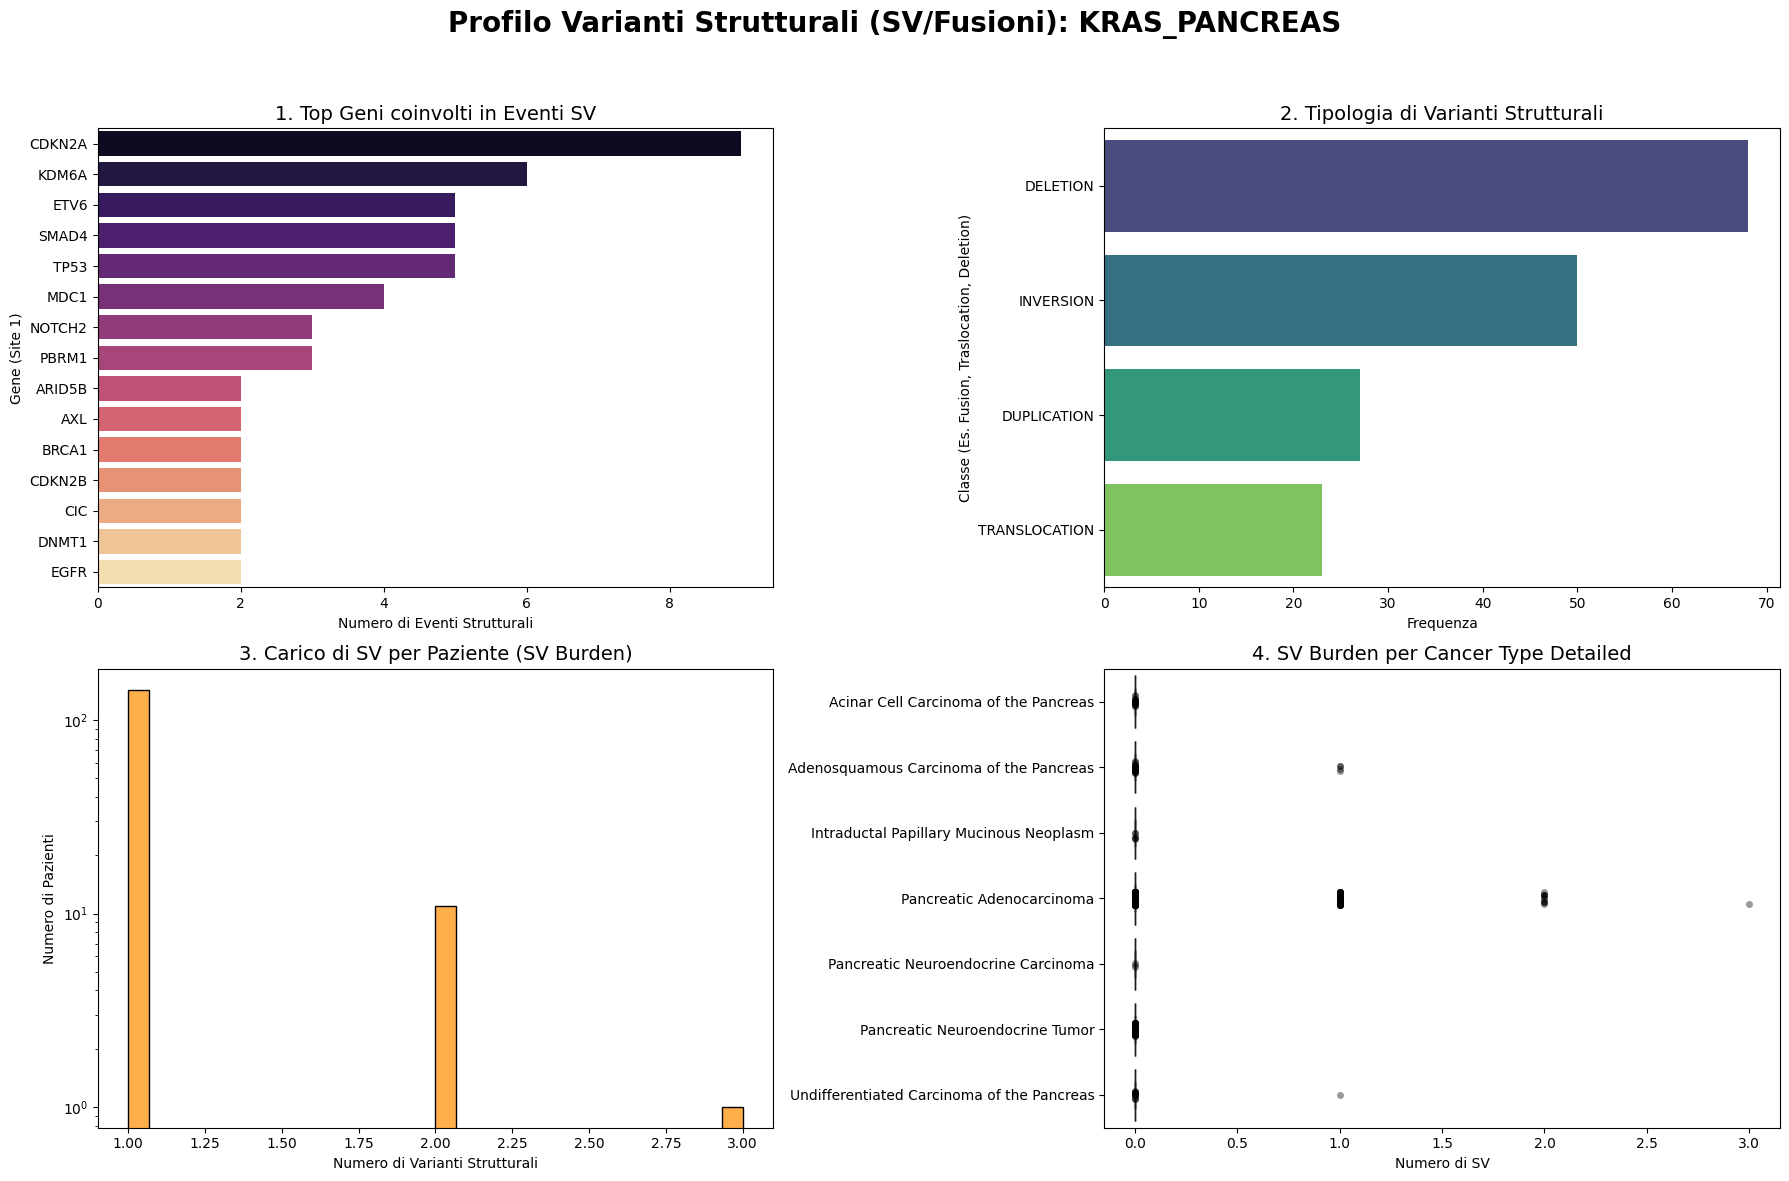

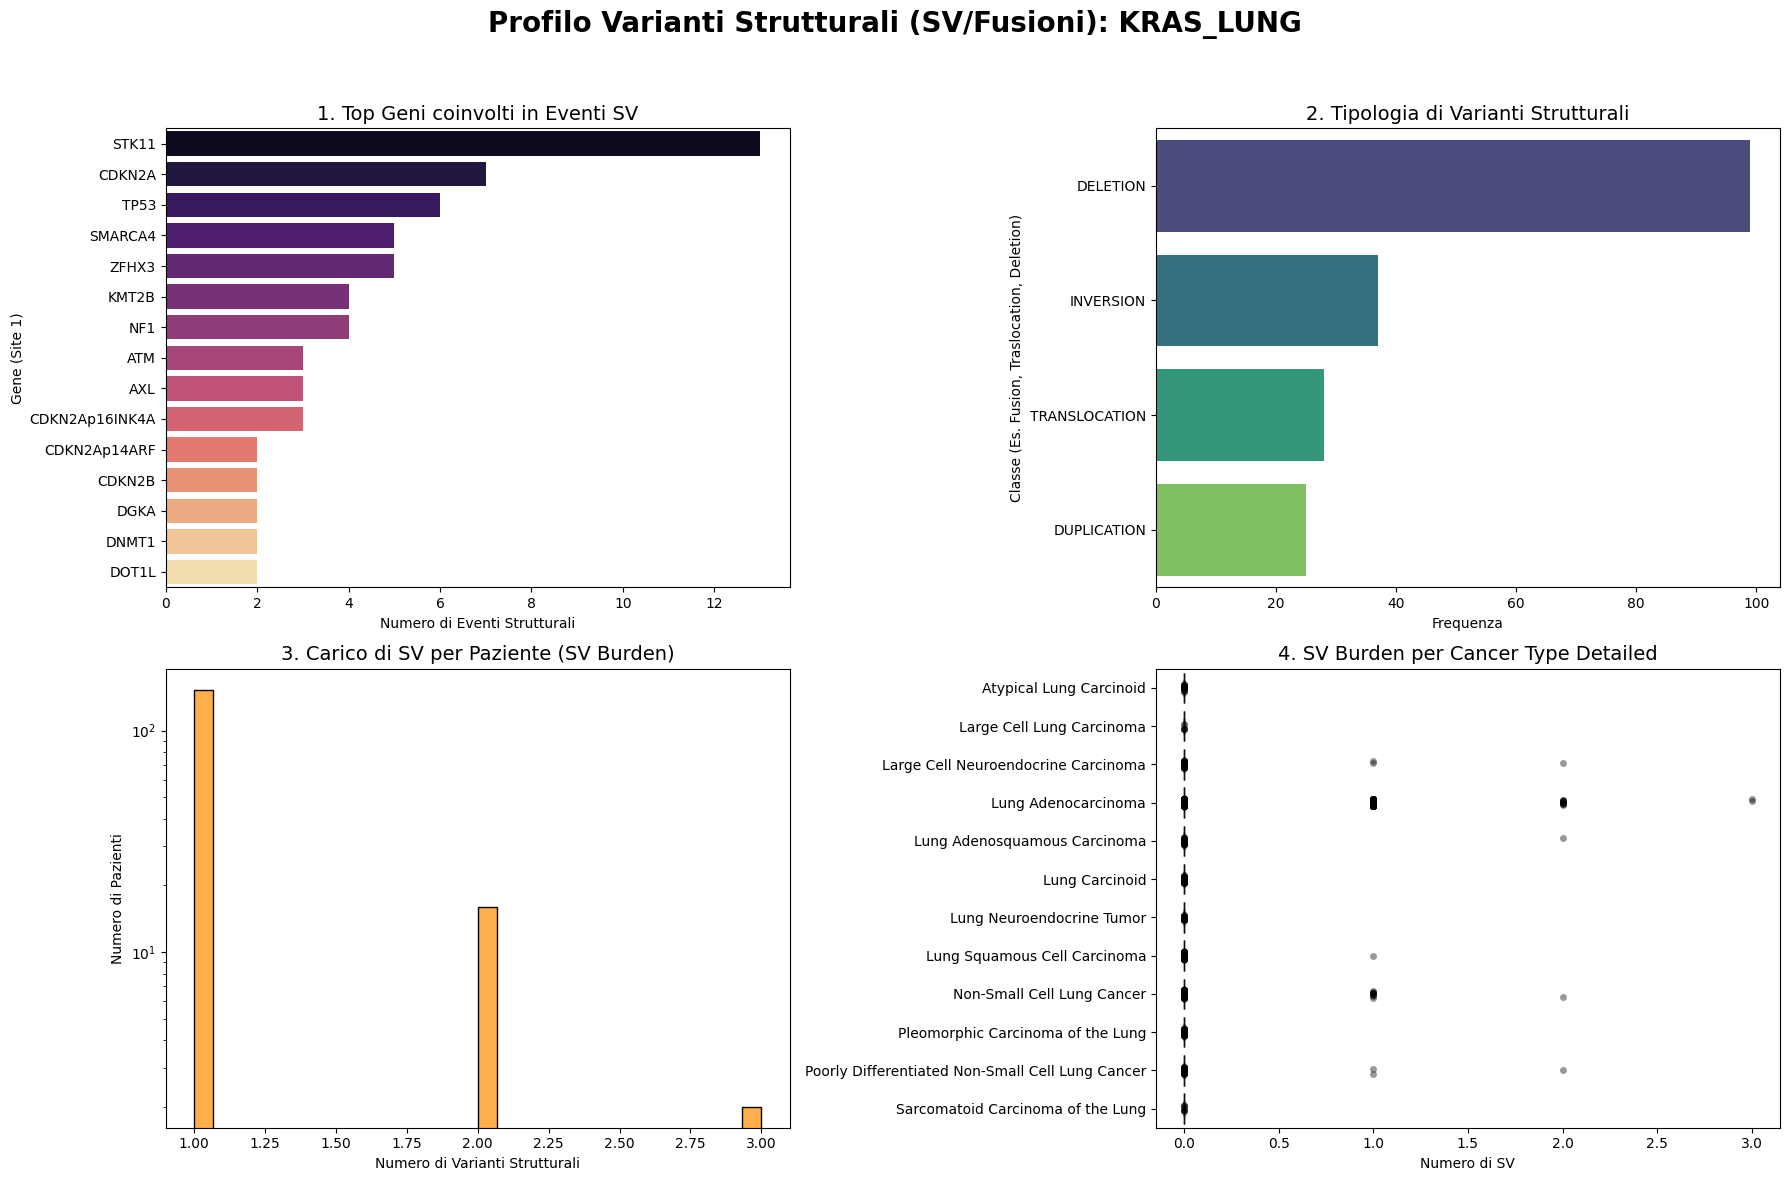

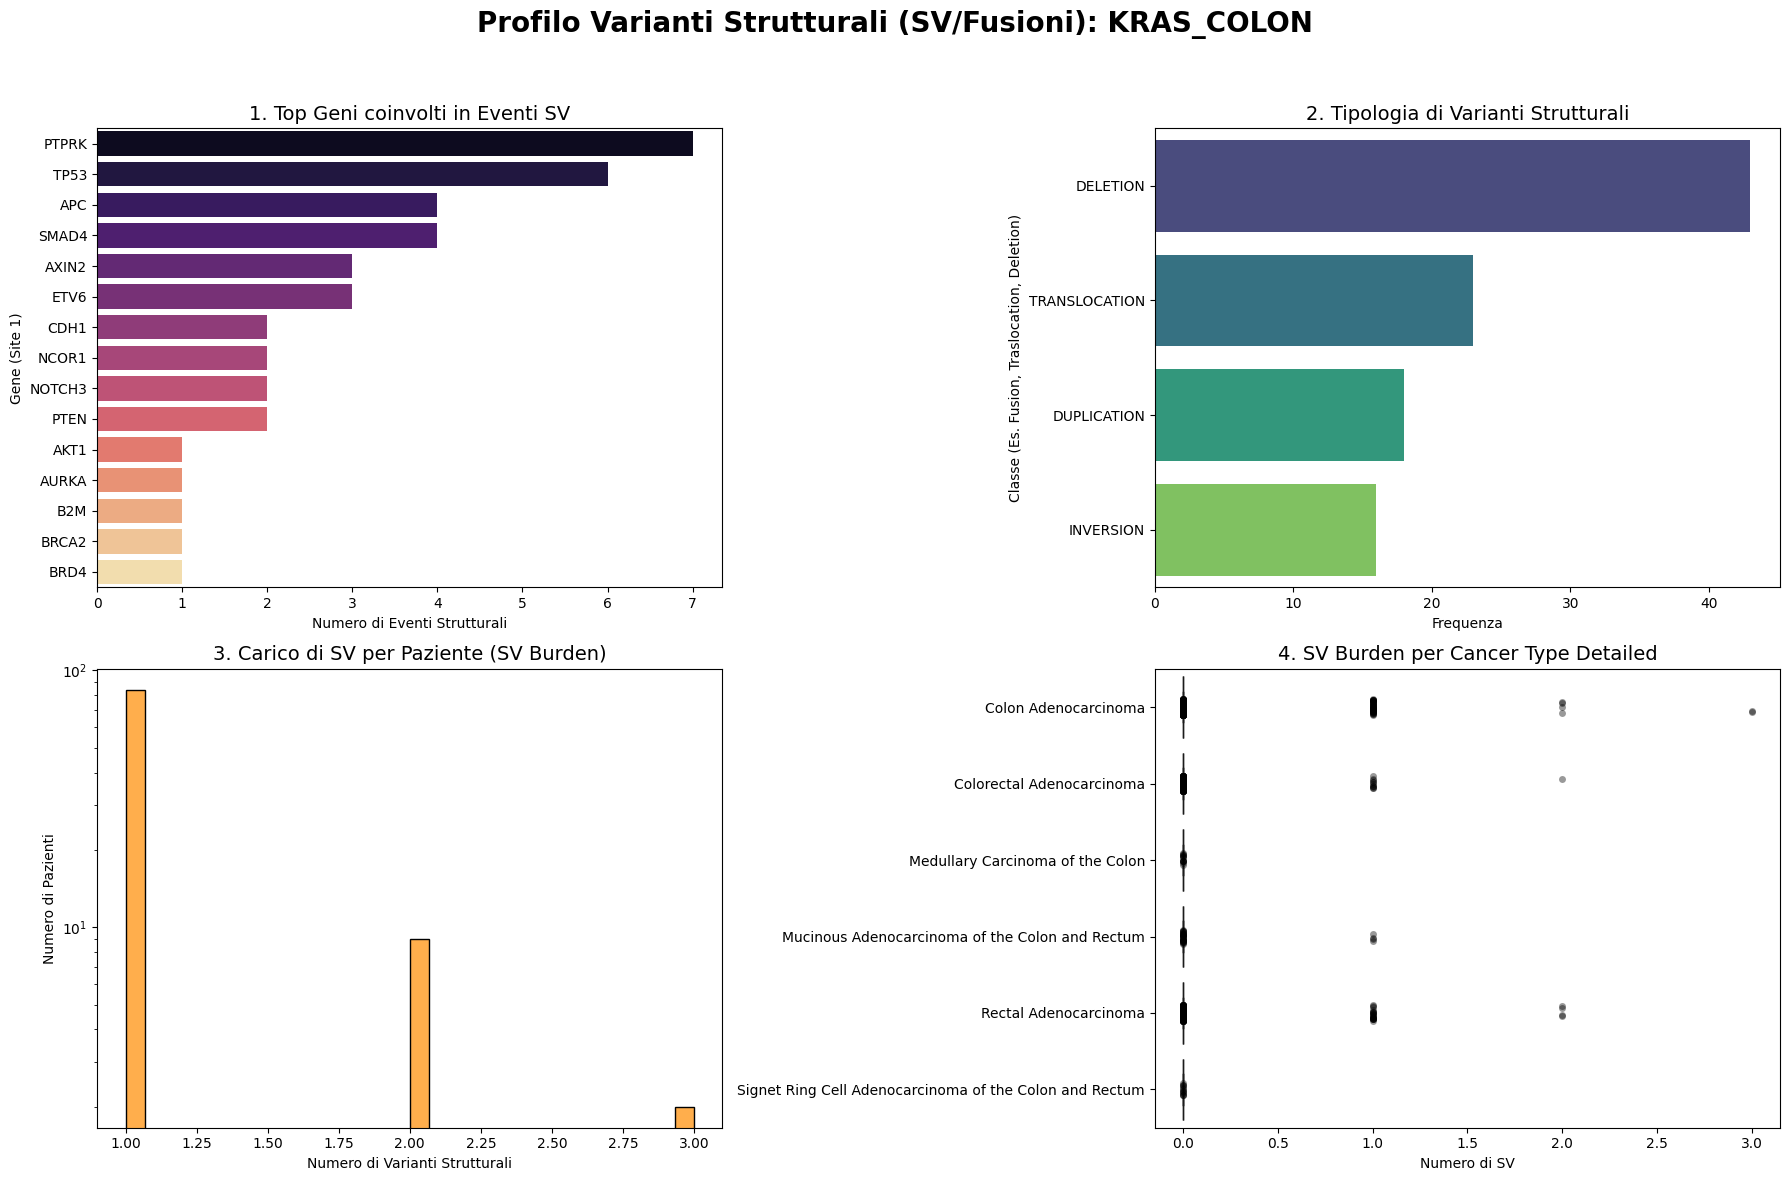

In [21]:
# --- ESECUZIONE ANALISI VARIANTI STRUTTURALI (SV) ---

sv_results = []
colonna_target = "Cancer Type Detailed"

# INSERISCI QUI IL NOME DEL TUO FILE FILTRATO CHE CONTIENE LE SV O LE FUSIONI:
# Di solito su cBioPortal si chiama data_sv.txt o data_fusions.txt
nome_file_sv = "F_data_sv.txt" 

# Analisi Pancreas
res_sv_panc = analyze_structural_variants(
    cohort_path="./kras_pancreas",
    master_filename="F_pancreas.csv",
    sv_filename=nome_file_sv,
    target_col=colonna_target
)
sv_results.append(res_sv_panc)

# Analisi Lung
res_sv_lung = analyze_structural_variants(
    cohort_path="./kras_lung",
    master_filename="F_lung.csv",
    sv_filename=nome_file_sv,
    target_col=colonna_target
)
sv_results.append(res_sv_lung)

# Analisi Colon
res_sv_colon = analyze_structural_variants(
    cohort_path="./kras_colon",
    master_filename="F_colon.csv",
    sv_filename=nome_file_sv,
    target_col=colonna_target
)
sv_results.append(res_sv_colon)

# Generazione Dashboard SV
print("\nGenerazione delle Dashboard SV in corso...")
plot_sv_dashboard(sv_results)